In [ ]:
# Plot frequencies by region with varying dates timeframes

## Geofigure 1 - Global Map

Global 4 panel figure: 
- October 2023 to May 2024
- October 2024 to May 2025
- October 2025 to May 2026
- panel D all time in the dataset (filter for latest and easliest sequence in the dataset)

## Geofigure 2 
Region Frequcny Graph over time 
- Region 1
- Region 2
- Region 3
- Region 4
- Region 5

Add a red verticle line indicating the first detection of C.3.1 

### Geofigure United States


Saved → ../figures/map_subclades_global_country.png


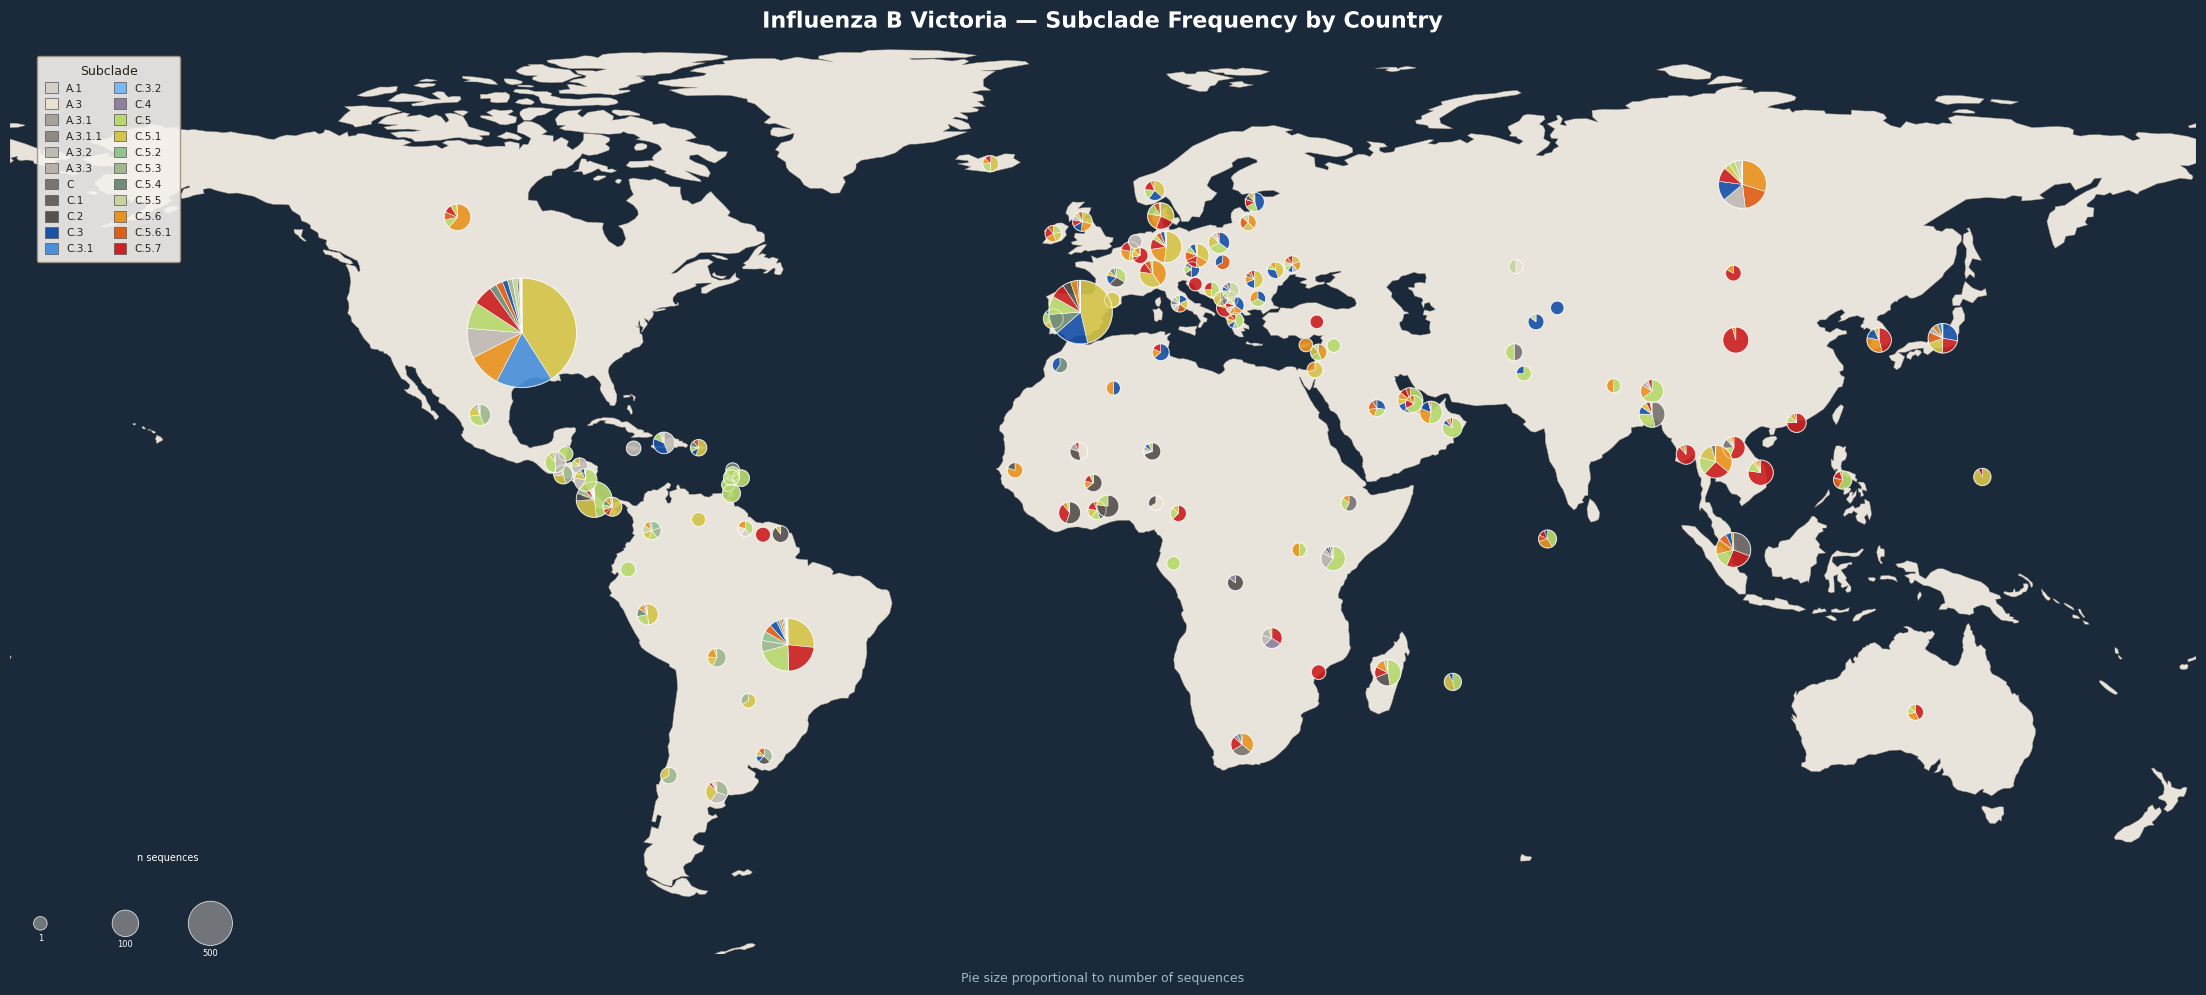

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
from geodatasets import get_path
from matplotlib.patches import Wedge
from collections import defaultdict

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(
    "../source/intermediate/vic/ha/metadata_qc_location_clades_dedup_clades.tsv",
    sep="\t",
    low_memory=False,
)

# Keep only rows with both country and subclade
df = df[df["country"].notna() & df["subclade"].notna()].copy()
df["country"] = df["country"].str.strip()
df["subclade"] = df["subclade"].str.strip()

# ── 2. Country → (lat, lon) lookup ───────────────────────────────────────────
COUNTRY_COORDS = {
    "Afghanistan": (33.9, 67.7), "Albania": (41.2, 20.2), "Algeria": (28.0, 1.7),
    "Andorra": (42.5, 1.5), "Argentina": (-38.4, -63.6), "Australia": (-25.3, 133.8),
    "Austria": (47.5, 14.6), "Bahrain": (26.0, 50.6), "Bangladesh": (23.7, 90.4),
    "Barbados": (13.2, -59.6), "Belgium": (50.5, 4.5), "Belize": (17.2, -88.5),
    "Bhutan": (27.5, 90.4), "Bolivia": (-16.3, -63.6), "Bosnia and Herzegovina": (44.2, 17.9),
    "Brazil": (-14.2, -51.9), "Bulgaria": (42.7, 25.5), "Burkina Faso": (12.4, -1.6),
    "Cameroon": (7.4, 12.4), "Canada": (56.1, -106.3), "Chile": (-35.7, -71.5),
    "China": (35.9, 104.2), "Colombia": (4.6, -74.3), "Costa Rica": (9.7, -83.8),
    "Congo, the Democatic Republic of": (-4.0, 21.8), "Cote d'Ivoire": (7.5, -5.5),
    "Croatia": (45.1, 15.2), "Cyprus": (35.1, 33.4), "Czech Republic": (49.8, 15.5),
    "Denmark": (56.3, 9.5), "Ecuador": (-1.8, -78.2), "El Salvador": (13.8, -88.9),
    "Estonia": (58.6, 25.0), "Ethiopia": (9.1, 40.5), "France": (46.2, 2.2),
    "French Guiana": (4.0, -53.1), "Gabon": (-0.8, 11.6), "Germany": (51.2, 10.4),
    "Ghana": (7.9, -1.0), "Greece": (39.1, 21.8), "Grenada": (12.1, -61.7),
    "Guam": (13.4, 144.8), "Guatemala": (15.8, -90.2), "Guyana": (4.9, -58.9),
    "Haiti": (19.0, -72.3), "Honduras": (15.2, -86.2), "Hong Kong (SAR)": (22.3, 114.2),
    "Iceland": (64.9, -18.5), "Ireland": (53.4, -8.2), "Israel": (31.0, 34.9),
    "Italy": (41.9, 12.6), "Jamaica": (18.1, -77.3), "Japan": (36.2, 138.3),
    "Kazakhstan": (48.0, 68.0), "Kenya": (0.0, 37.9), "Korea, Republic of": (35.9, 127.8),
    "Kosovo": (42.6, 20.9), "Kyrgyzstan": (41.2, 74.8),
    "Lao, People's Democratic Republic": (18.2, 103.9), "Lebanon": (33.9, 35.5),
    "Lithuania": (55.2, 23.9), "Luxembourg": (49.8, 6.1),
    "Macedonia, the former Yogoslav Republic of": (41.6, 21.7),
    "Madagascar": (-18.8, 46.9), "Maldives": (3.2, 73.2), "Mali": (17.6, -4.0),
    "Martinique": (14.6, -61.0), "Mauritius": (-20.3, 57.6), "Mexico": (23.6, -102.6),
    "Moldova, Republic of": (47.4, 28.4), "Mongolia": (46.9, 103.8),
    "Montenegro": (42.7, 19.4), "Morocco": (31.8, -7.1), "Mozambique": (-18.7, 35.5),
    "Myanmar": (17.1, 96.0), "Nepal": (28.4, 84.1), "Netherlands": (52.1, 5.3),
    "Nicaragua": (12.9, -85.2), "Niger": (17.6, 8.1), "Nigeria": (9.1, 8.7),
    "Norway": (60.5, 8.5), "Oman": (21.5, 57.5), "Pakistan": (30.4, 69.3),
    "Panama": (8.5, -80.8), "Paraguay": (-23.4, -58.4), "Peru": (-9.2, -75.0),
    "Philippines": (12.9, 121.8), "Poland": (51.9, 19.1), "Portugal": (39.4, -8.2),
    "Puerto Rico": (18.2, -66.6), "Qatar": (25.4, 51.2), "Romania": (45.9, 24.9),
    "Russian Federation": (61.5, 105.3), "Saint Lucia": (13.9, -61.0),
    "Saint Vincent and the Grenadines": (13.3, -61.2), "Saudi Arabia": (24.7, 45.1),
    "Senegal": (14.5, -14.5), "Serbia": (44.0, 21.0), "Singapore": (1.4, 103.8),
    "Slovakia": (48.7, 19.7), "South Africa": (-30.6, 22.9), "Spain": (40.5, -3.7),
    "Suriname": (3.9, -56.0), "Switzerland": (46.8, 8.2), "Syrian Arab Republic": (35.0, 38.0),
    "Tajikistan": (38.9, 71.3), "Thailand": (15.9, 100.9), "Togo": (8.6, 0.8),
    "Trinidad and Tobago": (10.7, -61.2), "Tunisia": (33.9, 9.5), "Turkey": (38.9, 35.2),
    "Uganda": (1.4, 32.3), "Ukraine": (48.4, 31.2), "United Arab Emirates": (24.0, 54.0),
    "United Kingdom": (55.4, -3.4), "United States": (37.1, -95.7),
    "Uruguay": (-32.5, -55.8), "Venezuela": (6.4, -66.6), "Vietnam": (14.1, 108.3),
    "Zambia": (-13.1, 27.8),
    # Local institution fallback
    "JHH": (39.3, -76.6),
}

# ── 3. Subclade colour palette (matches inspiration image style) ──────────────
SUBCLADE_COLORS = {
    "C.3":     "#1a52a8",   # deep blue
    "C.3.1":   "#4a90d9",   # mid blue
    "C.3.2":   "#7ab8f5",   # light blue
    "C.5":     "#b8d96e",   # yellow-green
    "C.5.1":   "#d4c44a",   # golden yellow
    "C.5.6":   "#e89320",   # amber
    "C.5.6.1": "#e05f18",   # burnt orange
    "C.5.7":   "#cc2222",   # red
    "A.3":     "#e8e0d0",   # light sand
    "A.1":     "#d4cfc8",   # light grey-beige
    "A.3.2":   "#c0bab4",   # medium grey
    "A.3.1":   "#a8a29c",   # grey
    "A.3.1.1": "#918a84",   # dark grey
    "C":       "#7a7470",   # charcoal grey
    "C.1":     "#6a6460",   # dark charcoal
    "C.2":     "#58524e",   # very dark
    "C.3.3":   "#b0a8e0",   # lavender
    "C.5.2":   "#90c490",   # sage green
    "C.5.4":   "#708c78",   # muted teal
    "C.5.3":   "#a0b890",   # grey-green
    "C.5.5":   "#c8d4a0",   # pale green
    "A":       "#e0dcd8",   # very light
    "A.3.3":   "#b8b0ac",   # mid grey
    "C.4":     "#9080a0",   # muted purple
}
DEFAULT_COLOR = "#aaaaaa"

# ── 4. Aggregate counts by country × subclade ─────────────────────────────────
counts = (
    df.groupby(["country", "subclade"])
    .size()
    .reset_index(name="n")
)

country_totals = counts.groupby("country")["n"].sum()

# Only keep countries we have coordinates for
valid_countries = [c for c in counts["country"].unique() if c in COUNTRY_COORDS]
counts = counts[counts["country"].isin(valid_countries)]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
world = gpd.read_file(get_path("naturalearth.land"))


fig, ax = plt.subplots(1, 1, figsize=(22, 13), facecolor="#1a2a3a")
ax.set_facecolor("#2a4a6a")

# Draw world base map
world.plot(ax=ax, color="#e8e4dc", edgecolor="#a09080", linewidth=0.3, zorder=1)

ax.set_xlim(-180, 180)
ax.set_ylim(-65, 85)
ax.axis("off")

# ── 6. Draw pie charts per country ───────────────────────────────────────────
max_n = country_totals.max()
MIN_R, MAX_R = 1.0, 9.0   # radius in degrees

for country, grp in counts.groupby("country"):
    lat, lon = COUNTRY_COORDS[country]
    total = grp["n"].sum()
    scale = np.sqrt(total / max_n)
    radius = MIN_R + (MAX_R - MIN_R) * scale

    # Build pie wedges (in data/degree space directly)
    slices = grp.sort_values("n", ascending=False)
    angles = (slices["n"] / total * 360).values
    subclades = slices["subclade"].values

    start = 90.0
    for angle, sc in zip(angles, subclades):
        color = SUBCLADE_COLORS.get(sc, DEFAULT_COLOR)
        wedge = Wedge(
            (lon, lat),
            radius,
            start - angle,
            start,
            facecolor=color,
            edgecolor="white",
            linewidth=0.4,
            alpha=0.92,
            zorder=5,
        )
        ax.add_patch(wedge)
        start -= angle

    # White border ring
    ring = plt.Circle((lon, lat), radius, fill=False, edgecolor="white",
                      linewidth=0.8, alpha=0.5, zorder=6)
    ax.add_patch(ring)

# ── 7. Legend ─────────────────────────────────────────────────────────────────
legend_subclades = sorted(SUBCLADE_COLORS.keys())
handles = [
    mpatches.Patch(facecolor=SUBCLADE_COLORS[sc], edgecolor="#555", linewidth=0.5, label=sc)
    for sc in legend_subclades
    if sc in df["subclade"].values
]

legend = ax.legend(
    handles=handles,
    title="Subclade",
    title_fontsize=9,
    fontsize=7.5,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=2,
    framealpha=0.90,
    facecolor="#f5f2ee",
    edgecolor="#a09080",
    labelcolor="#2a2018",
    handlelength=1.2,
    handleheight=1.2,
    columnspacing=1.0,
    borderpad=0.8,
)
legend.get_title().set_color("#2a2018")

# Size reference inset (bottom-left corner of the main axes)
ref_sizes = [1, 100, 500]
ref_labels = ["1", "100", "500"]
bx = -175
by = -60
spacing = 14
ax.text(bx + spacing * 1.5, by + 10, "n sequences",
        ha="center", va="bottom", fontsize=7, color="white", zorder=10)
for i, (s, lbl) in enumerate(zip(ref_sizes, ref_labels)):
    r = MIN_R + (MAX_R - MIN_R) * np.sqrt(s / max_n)
    cx = bx + i * spacing
    cy = by
    c = plt.Circle((cx, cy), r, facecolor="#888", edgecolor="white",
                   linewidth=0.6, alpha=0.8, zorder=10)
    ax.add_patch(c)
    ax.text(cx, cy - r - 0.5, lbl, ha="center", va="top",
            fontsize=6, color="white", zorder=10)

# Title
ax.set_title(
    "Influenza B Victoria — Subclade Frequency by Country",
    fontsize=16, fontweight="bold", color="white", pad=10,
    path_effects=[pe.withStroke(linewidth=3, foreground="#1a2a3a")]
)
ax.text(0.5, -0.02, "Pie size proportional to number of sequences",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=9, color="#a0b8c8")

plt.tight_layout(pad=0.5)
out = "../figures/map_subclades_global_country.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out}")


In [ ]:
# Plot byregion

Sequence counts per region:
custom_region
North America    5274
Europe           2113
South America     975
West Asia         854
East Asia         759
Africa            480
Japan/Korea       222
South Asia        173
Oceania             7
Saved → ../figures/map_subclades_global_region.png


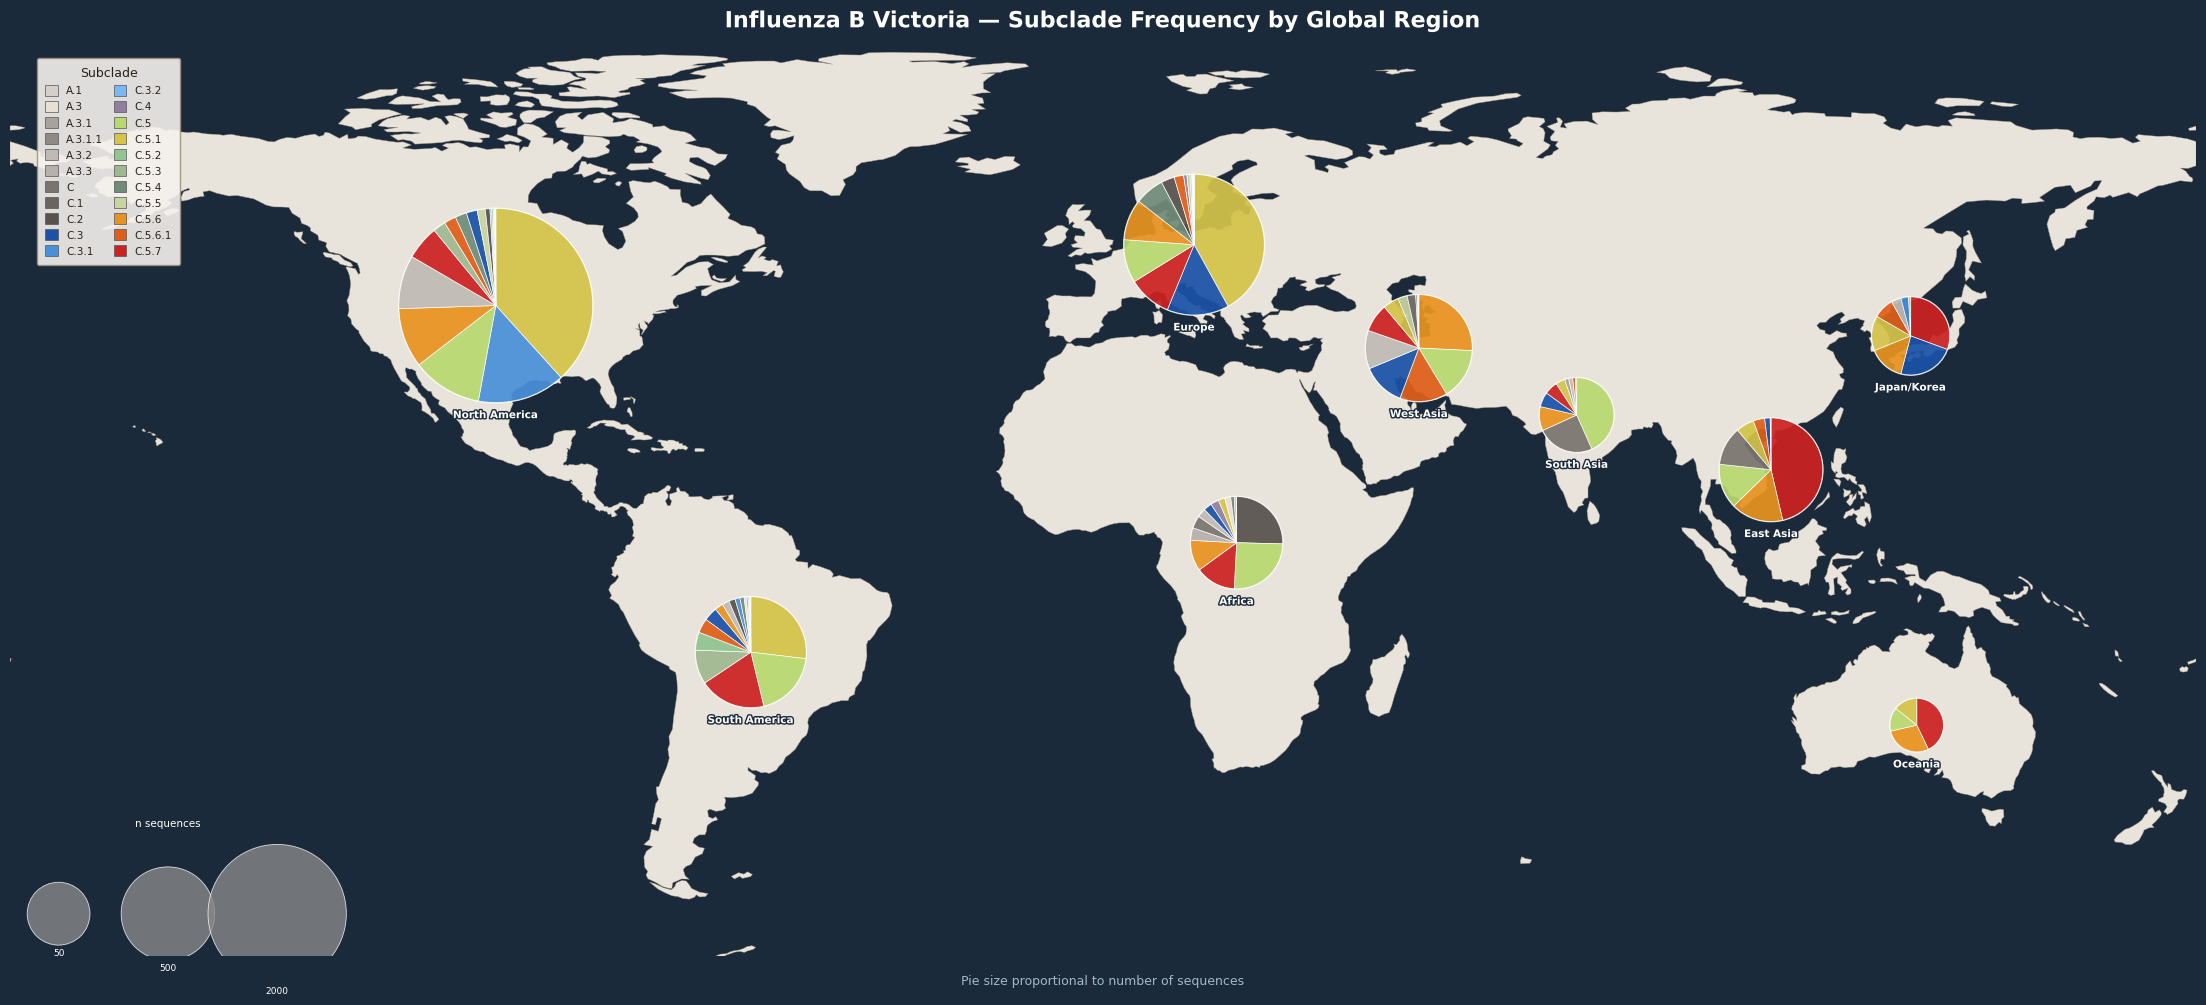

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
from geodatasets import get_path
from matplotlib.patches import Wedge
from collections import defaultdict

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(
    "../source/intermediate/vic/ha/metadata_qc_location_clades_dedup_clades.tsv",
    sep="\t",
    low_memory=False,
)

df = df[df["country"].notna() & df["subclade"].notna()].copy()
df["country"]  = df["country"].str.strip()
df["subclade"] = df["subclade"].str.strip()

# ── 2. Country → custom region mapping ───────────────────────────────────────
COUNTRY_TO_REGION = {
    # North America
    "Canada": "North America", "United States": "North America", "Mexico": "North America",
    "Cuba": "North America", "Jamaica": "North America", "Haiti": "North America",
    "Puerto Rico": "North America", "Trinidad and Tobago": "North America",
    "Barbados": "North America", "Grenada": "North America",
    "Saint Lucia": "North America", "Saint Vincent and the Grenadines": "North America",
    "Guam": "North America", "Martinique": "North America", "Belize": "North America",
    "Guatemala": "North America", "Honduras": "North America", "El Salvador": "North America",
    "Nicaragua": "North America", "Costa Rica": "North America", "Panama": "North America",
    "JHH": "North America",

    # South America
    "Colombia": "South America", "Venezuela": "South America", "Brazil": "South America",
    "Peru": "South America", "Ecuador": "South America", "Bolivia": "South America",
    "Chile": "South America", "Argentina": "South America", "Uruguay": "South America",
    "Paraguay": "South America", "Guyana": "South America", "Suriname": "South America",
    "French Guiana": "South America",

    # Europe
    "United Kingdom": "Europe", "France": "Europe", "Germany": "Europe",
    "Spain": "Europe", "Italy": "Europe", "Portugal": "Europe", "Netherlands": "Europe",
    "Belgium": "Europe", "Switzerland": "Europe", "Austria": "Europe", "Norway": "Europe",
    "Denmark": "Europe", "Sweden": "Europe", "Finland": "Europe", "Iceland": "Europe",
    "Ireland": "Europe", "Poland": "Europe", "Czech Republic": "Europe",
    "Slovakia": "Europe", "Romania": "Europe", "Bulgaria": "Europe", "Greece": "Europe",
    "Croatia": "Europe", "Serbia": "Europe", "Bosnia and Herzegovina": "Europe",
    "Montenegro": "Europe", "Kosovo": "Europe", "Albania": "Europe",
    "Macedonia, the former Yogoslav Republic of": "Europe",
    "Moldova, Republic of": "Europe", "Ukraine": "Europe", "Estonia": "Europe",
    "Lithuania": "Europe", "Luxembourg": "Europe", "Andorra": "Europe", "Cyprus": "Europe",

    # Africa
    "Morocco": "Africa", "Algeria": "Africa", "Tunisia": "Africa", "Nigeria": "Africa",
    "Ghana": "Africa", "Senegal": "Africa", "Mali": "Africa", "Niger": "Africa",
    "Burkina Faso": "Africa", "Cameroon": "Africa", "Gabon": "Africa",
    "Congo, the Democatic Republic of": "Africa", "Kenya": "Africa", "Uganda": "Africa",
    "Ethiopia": "Africa", "South Africa": "Africa", "Mozambique": "Africa",
    "Zambia": "Africa", "Madagascar": "Africa", "Mauritius": "Africa",
    "Togo": "Africa", "Cote d'Ivoire": "Africa", "Sudan, South": "Africa",

    # West Asia (Middle East + Central Asia)
    "Turkey": "West Asia", "Lebanon": "West Asia", "Israel": "West Asia",
    "Syrian Arab Republic": "West Asia", "Saudi Arabia": "West Asia",
    "Oman": "West Asia", "Qatar": "West Asia", "Bahrain": "West Asia",
    "United Arab Emirates": "West Asia", "Kazakhstan": "West Asia",
    "Kyrgyzstan": "West Asia", "Tajikistan": "West Asia", "Afghanistan": "West Asia",
    "Russian Federation": "West Asia",

    # South Asia
    "Pakistan": "South Asia", "Bangladesh": "South Asia", "Nepal": "South Asia",
    "Bhutan": "South Asia", "Maldives": "South Asia",

    # East & Southeast Asia
    "China": "East Asia", "Hong Kong (SAR)": "East Asia", "Mongolia": "East Asia",
    "Vietnam": "East Asia", "Thailand": "East Asia", "Myanmar": "East Asia",
    "Lao, People's Democratic Republic": "East Asia", "Singapore": "East Asia",
    "Philippines": "East Asia",

    # Japan / Korea
    "Japan": "Japan/Korea", "Korea, Republic of": "Japan/Korea",

    # Oceania
    "Australia": "Oceania", "New Zealand": "Oceania", "Papua New Guinea": "Oceania",
}

# Central coordinates for each region label/pie
REGION_COORDS = {
    "North America":  (42.0, -100.0),
    "South America":  (-15.0,  -58.0),
    "Europe":         (52.0,   15.0),
    "Africa":         (3.0,    22.0),
    "West Asia":      (35.0,   52.0),
    "South Asia":     (24.0,   78.0),
    "East Asia":      (15.0,  110.0),
    "Japan/Korea":    (37.0,  133.0),
    "Oceania":        (-27.0, 134.0),
}

# ── 3. Subclade colour palette ────────────────────────────────────────────────
SUBCLADE_COLORS = {
    "C.3":     "#1a52a8",
    "C.3.1":   "#4a90d9",
    "C.3.2":   "#7ab8f5",
    "C.5":     "#b8d96e",
    "C.5.1":   "#d4c44a",
    "C.5.6":   "#e89320",
    "C.5.6.1": "#e05f18",
    "C.5.7":   "#cc2222",
    "A.3":     "#e8e0d0",
    "A.1":     "#d4cfc8",
    "A.3.2":   "#c0bab4",
    "A.3.1":   "#a8a29c",
    "A.3.1.1": "#918a84",
    "C":       "#7a7470",
    "C.1":     "#6a6460",
    "C.2":     "#58524e",
    "C.3.3":   "#b0a8e0",
    "C.5.2":   "#90c490",
    "C.5.4":   "#708c78",
    "C.5.3":   "#a0b890",
    "C.5.5":   "#c8d4a0",
    "A":       "#e0dcd8",
    "A.3.3":   "#b8b0ac",
    "C.4":     "#9080a0",
}
DEFAULT_COLOR = "#aaaaaa"

# ── 4. Aggregate counts by custom region × subclade ───────────────────────────
df["custom_region"] = df["country"].map(COUNTRY_TO_REGION)
df = df[df["custom_region"].notna()]

counts = (
    df.groupby(["custom_region", "subclade"])
    .size()
    .reset_index(name="n")
)

region_totals = counts.groupby("custom_region")["n"].sum()
print("Sequence counts per region:")
print(region_totals.sort_values(ascending=False).to_string())

# ── 5. Base map ───────────────────────────────────────────────────────────────
world = gpd.read_file(get_path("naturalearth.land"))

fig, ax = plt.subplots(1, 1, figsize=(22, 13), facecolor="#1a2a3a")
ax.set_facecolor("#2a4a6a")
world.plot(ax=ax, color="#e8e4dc", edgecolor="#a09080", linewidth=0.3, zorder=1)
ax.set_xlim(-180, 180)
ax.set_ylim(-65, 85)
ax.axis("off")

# ── 6. Draw pie charts per region ─────────────────────────────────────────────
max_n  = region_totals.max()
MIN_R  = 4.0
MAX_R  = 16.0

for region, grp in counts.groupby("custom_region"):
    lat, lon = REGION_COORDS[region]
    total    = grp["n"].sum()
    scale    = np.sqrt(total / max_n)
    radius   = MIN_R + (MAX_R - MIN_R) * scale

    slices   = grp.sort_values("n", ascending=False)
    angles   = (slices["n"] / total * 360).values
    subclades = slices["subclade"].values

    start = 90.0
    for angle, sc in zip(angles, subclades):
        color = SUBCLADE_COLORS.get(sc, DEFAULT_COLOR)
        wedge = Wedge(
            (lon, lat),
            radius,
            start - angle,
            start,
            facecolor=color,
            edgecolor="white",
            linewidth=0.5,
            alpha=0.93,
            zorder=5,
        )
        ax.add_patch(wedge)
        start -= angle

    # Outline ring
    ring = plt.Circle((lon, lat), radius, fill=False, edgecolor="white",
                      linewidth=1.0, alpha=0.6, zorder=6)
    ax.add_patch(ring)

    # Region label below each pie
    ax.text(lon, lat - radius - 1.2, region,
            ha="center", va="top", fontsize=7.5, color="white",
            fontweight="bold", zorder=7,
            path_effects=[pe.withStroke(linewidth=2, foreground="#1a2a3a")])

# ── 7. Legend ─────────────────────────────────────────────────────────────────
present_subclades = sorted(df["subclade"].unique())
handles = [
    mpatches.Patch(
        facecolor=SUBCLADE_COLORS.get(sc, DEFAULT_COLOR),
        edgecolor="#555", linewidth=0.5, label=sc
    )
    for sc in present_subclades
]

legend = ax.legend(
    handles=handles,
    title="Subclade",
    title_fontsize=9,
    fontsize=7.5,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=2,
    framealpha=0.90,
    facecolor="#f5f2ee",
    edgecolor="#a09080",
    labelcolor="#2a2018",
    handlelength=1.2,
    handleheight=1.2,
    columnspacing=1.0,
    borderpad=0.8,
)
legend.get_title().set_color("#2a2018")

# ── 8. Size reference circles ─────────────────────────────────────────────────
ref_sizes  = [50, 500, 2000]
ref_labels = ["50", "500", "2000"]
bx, by, spacing = -172, -58, 18

ax.text(bx + spacing, by + 14, "n sequences",
        ha="center", va="bottom", fontsize=7.5, color="white", zorder=10)

for i, (s, lbl) in enumerate(zip(ref_sizes, ref_labels)):
    r  = MIN_R + (MAX_R - MIN_R) * np.sqrt(s / max_n)
    cx = bx + i * spacing
    cy = by
    c  = plt.Circle((cx, cy), r, facecolor="#888", edgecolor="white",
                    linewidth=0.6, alpha=0.8, zorder=10)
    ax.add_patch(c)
    ax.text(cx, cy - r - 0.5, lbl, ha="center", va="top",
            fontsize=6.5, color="white", zorder=10)

# ── 9. Title ──────────────────────────────────────────────────────────────────
ax.set_title(
    "Influenza B Victoria — Subclade Frequency by Global Region",
    fontsize=16, fontweight="bold", color="white", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#1a2a3a")]
)
ax.text(0.5, -0.02, "Pie size proportional to number of sequences",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=9, color="#a0b8c8")

plt.tight_layout(pad=0.5)
out = "../figures/map_subclades_global_region.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out}")


# 4 panel map frequency

Saved → ../figures/map_subclades_global_region_4panel.png


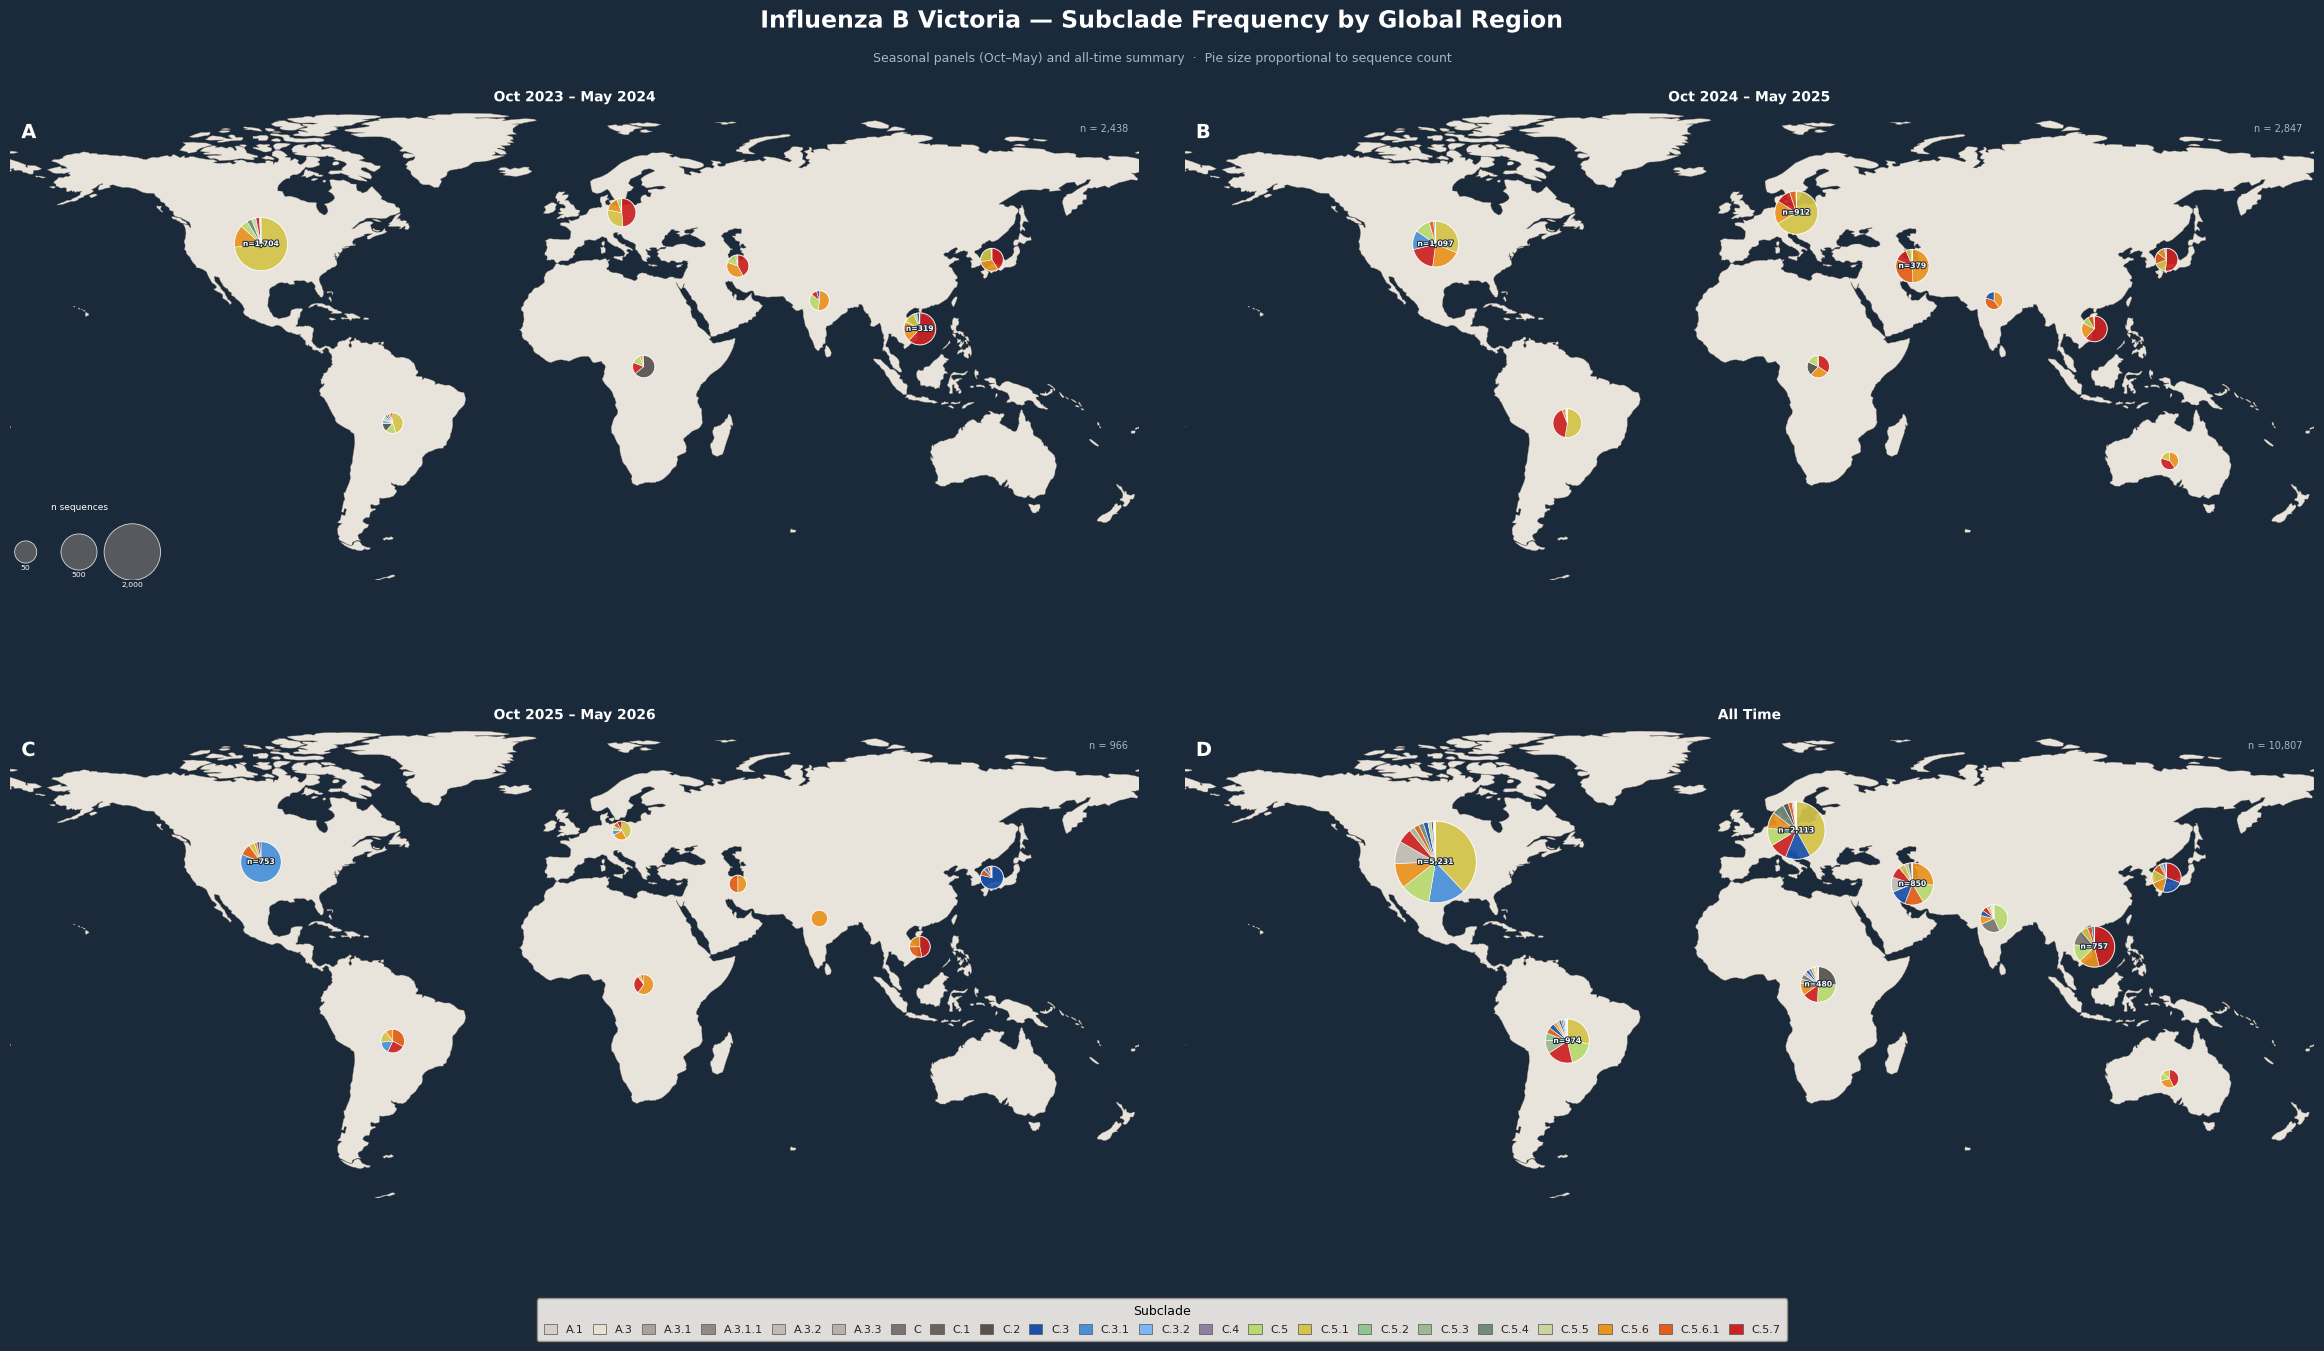

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
from geodatasets import get_path
from matplotlib.patches import Wedge
from collections import defaultdict

# ── 1. Load data ──────────────────────────────────────────────────────────────

df = pd.read_csv(
    "../source/intermediate/vic/ha/metadata_qc_location_clades_dedup_clades.tsv",
    sep="\t",
    low_memory=False,
)

df = df[df["country"].notna() & df["subclade"].notna()].copy()
df["country"]  = df["country"].str.strip()
df["subclade"] = df["subclade"].str.strip()
df["date"]     = pd.to_datetime(df["date"], errors="coerce")

# ── 2. Country → custom region mapping ───────────────────────────────────────
COUNTRY_TO_REGION = {
    # North America
    "Canada": "North America", "United States": "North America", "Mexico": "North America",
    "Cuba": "North America", "Jamaica": "North America", "Haiti": "North America",
    "Puerto Rico": "North America", "Trinidad and Tobago": "North America",
    "Barbados": "North America", "Grenada": "North America",
    "Saint Lucia": "North America", "Saint Vincent and the Grenadines": "North America",
    "Guam": "North America", "Martinique": "North America", "Belize": "North America",
    "Guatemala": "North America", "Honduras": "North America", "El Salvador": "North America",
    "Nicaragua": "North America", "Costa Rica": "North America", "Panama": "North America",
    "JHH": "North America",
    # South America
    "Colombia": "South America", "Venezuela": "South America", "Brazil": "South America",
    "Peru": "South America", "Ecuador": "South America", "Bolivia": "South America",
    "Chile": "South America", "Argentina": "South America", "Uruguay": "South America",
    "Paraguay": "South America", "Guyana": "South America", "Suriname": "South America",
    "French Guiana": "South America",
    # Europe
    "United Kingdom": "Europe", "France": "Europe", "Germany": "Europe",
    "Spain": "Europe", "Italy": "Europe", "Portugal": "Europe", "Netherlands": "Europe",
    "Belgium": "Europe", "Switzerland": "Europe", "Austria": "Europe", "Norway": "Europe",
    "Denmark": "Europe", "Sweden": "Europe", "Finland": "Europe", "Iceland": "Europe",
    "Ireland": "Europe", "Poland": "Europe", "Czech Republic": "Europe",
    "Slovakia": "Europe", "Romania": "Europe", "Bulgaria": "Europe", "Greece": "Europe",
    "Croatia": "Europe", "Serbia": "Europe", "Bosnia and Herzegovina": "Europe",
    "Montenegro": "Europe", "Kosovo": "Europe", "Albania": "Europe",
    "Macedonia, the former Yogoslav Republic of": "Europe",
    "Moldova, Republic of": "Europe", "Ukraine": "Europe", "Estonia": "Europe",
    "Lithuania": "Europe", "Luxembourg": "Europe", "Andorra": "Europe", "Cyprus": "Europe",
    # Africa
    "Morocco": "Africa", "Algeria": "Africa", "Tunisia": "Africa", "Nigeria": "Africa",
    "Ghana": "Africa", "Senegal": "Africa", "Mali": "Africa", "Niger": "Africa",
    "Burkina Faso": "Africa", "Cameroon": "Africa", "Gabon": "Africa",
    "Congo, the Democatic Republic of": "Africa", "Kenya": "Africa", "Uganda": "Africa",
    "Ethiopia": "Africa", "South Africa": "Africa", "Mozambique": "Africa",
    "Zambia": "Africa", "Madagascar": "Africa", "Mauritius": "Africa",
    "Togo": "Africa", "Cote d'Ivoire": "Africa", "Sudan, South": "Africa",
    # West Asia
    "Turkey": "West Asia", "Lebanon": "West Asia", "Israel": "West Asia",
    "Syrian Arab Republic": "West Asia", "Saudi Arabia": "West Asia",
    "Oman": "West Asia", "Qatar": "West Asia", "Bahrain": "West Asia",
    "United Arab Emirates": "West Asia", "Kazakhstan": "West Asia",
    "Kyrgyzstan": "West Asia", "Tajikistan": "West Asia", "Afghanistan": "West Asia",
    "Russian Federation": "West Asia",
    # South Asia
    "Pakistan": "South Asia", "Bangladesh": "South Asia", "Nepal": "South Asia",
    "Bhutan": "South Asia", "Maldives": "South Asia",
    # East & Southeast Asia
    "China": "East Asia", "Hong Kong (SAR)": "East Asia", "Mongolia": "East Asia",
    "Vietnam": "East Asia", "Thailand": "East Asia", "Myanmar": "East Asia",
    "Lao, People's Democratic Republic": "East Asia", "Singapore": "East Asia",
    "Philippines": "East Asia",
    # Japan / Korea
    "Japan": "Japan/Korea", "Korea, Republic of": "Japan/Korea",
    # Oceania
    "Australia": "Oceania", "New Zealand": "Oceania", "Papua New Guinea": "Oceania",
}

REGION_COORDS = {
    "North America":  (42.0, -100.0),
    "South America":  (-15.0,  -58.0),
    "Europe":         (52.0,   15.0),
    "Africa":         (3.0,    22.0),
    "West Asia":      (35.0,   52.0),
    "South Asia":     (24.0,   78.0),
    "East Asia":      (15.0,  110.0),
    "Japan/Korea":    (37.0,  133.0),
    "Oceania":        (-27.0, 134.0),
}

# ── 3. Subclade colour palette ────────────────────────────────────────────────
SUBCLADE_COLORS = {
    "C.3":     "#1a52a8",
    "C.3.1":   "#4a90d9",
    "C.3.2":   "#7ab8f5",
    "C.5":     "#b8d96e",
    "C.5.1":   "#d4c44a",
    "C.5.6":   "#e89320",
    "C.5.6.1": "#e05f18",
    "C.5.7":   "#cc2222",
    "A.3":     "#e8e0d0",
    "A.1":     "#d4cfc8",
    "A.3.2":   "#c0bab4",
    "A.3.1":   "#a8a29c",
    "A.3.1.1": "#918a84",
    "C":       "#7a7470",
    "C.1":     "#6a6460",
    "C.2":     "#58524e",
    "C.3.3":   "#b0a8e0",
    "C.5.2":   "#90c490",
    "C.5.4":   "#708c78",
    "C.5.3":   "#a0b890",
    "C.5.5":   "#c8d4a0",
    "A":       "#e0dcd8",
    "A.3.3":   "#b8b0ac",
    "C.4":     "#9080a0",
}
DEFAULT_COLOR = "#aaaaaa"

# ── 4. Map custom region + filter valid rows ──────────────────────────────────
df["custom_region"] = df["country"].map(COUNTRY_TO_REGION)
df = df[df["custom_region"].notna() & df["date"].notna()]

# ── 5. Define panels ──────────────────────────────────────────────────────────
PANELS = [
    ("A", "Oct 2023 – May 2024", "2023-10-01", "2024-05-31"),
    ("B", "Oct 2024 – May 2025", "2024-10-01", "2025-05-31"),
    ("C", "Oct 2025 – May 2026", "2025-10-01", "2026-05-31"),
    ("D", "All Time",            None,          None),
]

# ── 6. Pre-compute global max_n across ALL panels for consistent scaling ──────
all_counts = []
for _, _, start, end in PANELS:
    sub = df if start is None else df[(df["date"] >= start) & (df["date"] <= end)]
    counts = sub.groupby(["custom_region", "subclade"]).size().reset_index(name="n")
    region_totals = counts.groupby("custom_region")["n"].sum()
    all_counts.append(region_totals)

global_max_n = max(rt.max() for rt in all_counts if len(rt) > 0)

# ── 7. Load base map ──────────────────────────────────────────────────────────
# If this path doesn't exist on your machine, replace with one of:
#   world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))   # geopandas < 1.0
#   world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
world = gpd.read_file(get_path("naturalearth.land"))

# ── 8. Helper: draw one panel ─────────────────────────────────────────────────
MIN_R, MAX_R = 2.5, 13.0

def draw_panel(ax, panel_df, label, title):
    """Draw world map + subclade pies onto ax."""
    ax.set_facecolor("#2a4a6a")
    world.plot(ax=ax, color="#e8e4dc", edgecolor="#a09080", linewidth=0.25, zorder=1)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-65, 85)
    ax.axis("off")

    counts = (
        panel_df.groupby(["custom_region", "subclade"])
        .size()
        .reset_index(name="n")
    )
    region_totals = counts.groupby("custom_region")["n"].sum()

    for region, grp in counts.groupby("custom_region"):
        lat, lon  = REGION_COORDS[region]
        total     = region_totals[region]
        scale     = np.sqrt(total / global_max_n)
        radius    = MIN_R + (MAX_R - MIN_R) * scale

        slices    = grp.sort_values("n", ascending=False)
        angles    = (slices["n"] / total * 360).values
        subclades = slices["subclade"].values

        start = 90.0
        for angle, sc in zip(angles, subclades):
            color = SUBCLADE_COLORS.get(sc, DEFAULT_COLOR)
            wedge = Wedge(
                (lon, lat), radius,
                start - angle, start,
                facecolor=color, edgecolor="white",
                linewidth=0.4, alpha=0.93, zorder=5,
            )
            ax.add_patch(wedge)
            start -= angle

        ring = plt.Circle((lon, lat), radius, fill=False,
                          edgecolor="white", linewidth=0.8, alpha=0.55, zorder=6)
        ax.add_patch(ring)

        # n label inside pie if large enough
        if radius > 5:
            ax.text(lon, lat, f"n={total:,}",
                    ha="center", va="center", fontsize=5.5,
                    color="white", fontweight="bold", zorder=7,
                    path_effects=[pe.withStroke(linewidth=1.5, foreground="#1a2a3a")])

    # Panel letter + season title
    ax.text(0.01, 0.97, label, transform=ax.transAxes,
            fontsize=14, fontweight="bold", color="white", va="top",
            path_effects=[pe.withStroke(linewidth=3, foreground="#1a2a3a")])
    ax.text(0.5, 1.01, title, transform=ax.transAxes,
            fontsize=10, fontweight="bold", color="white",
            ha="center", va="bottom",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="#1a2a3a")])

    # Total sequences for this panel
    total_seqs = panel_df.shape[0]
    ax.text(0.99, 0.97, f"n = {total_seqs:,}", transform=ax.transAxes,
            fontsize=7, color="#a0b8c8", ha="right", va="top")

# ── 9. Build figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(24, 14), facecolor="#1a2a3a")
fig.subplots_adjust(hspace=0.08, wspace=0.04, top=0.92, bottom=0.07,
                    left=0.02, right=0.98)

for ax, (label, title, start, end) in zip(axes.flat, PANELS):
    panel_df = df if start is None else df[(df["date"] >= start) & (df["date"] <= end)]
    draw_panel(ax, panel_df, label, title)

# ── 10. Shared legend ─────────────────────────────────────────────────────────
present_subclades = sorted(df["subclade"].unique())
handles = [
    mpatches.Patch(
        facecolor=SUBCLADE_COLORS.get(sc, DEFAULT_COLOR),
        edgecolor="#555", linewidth=0.5, label=sc
    )
    for sc in present_subclades
]

fig.legend(
    handles=handles,
    title="Subclade",
    title_fontsize=9,
    fontsize=8,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=len(present_subclades),
    framealpha=0.90,
    facecolor="#f5f2ee",
    edgecolor="#a09080",
    labelcolor="#2a2018",
    handlelength=1.2,
    handleheight=1.0,
    columnspacing=0.8,
    borderpad=0.6,
)

# ── 11. Size reference (bottom-left of panel A) ───────────────────────────────
ref_ax = axes[0, 0]
ref_sizes  = [50, 500, 2000]
ref_labels = ["50", "500", "2,000"]
bx, by, spacing = -175, -56, 17

ref_ax.text(bx + spacing, by + 13, "n sequences",
            ha="center", va="bottom", fontsize=6.5, color="white", zorder=10)
for i, (s, lbl) in enumerate(zip(ref_sizes, ref_labels)):
    r  = MIN_R + (MAX_R - MIN_R) * np.sqrt(s / global_max_n)
    cx = bx + i * spacing
    c  = plt.Circle((cx, by), r, facecolor="#666", edgecolor="white",
                    linewidth=0.6, alpha=0.8, zorder=10)
    ref_ax.add_patch(c)
    ref_ax.text(cx, by - r - 0.4, lbl, ha="center", va="top",
                fontsize=5.5, color="white", zorder=10)

# ── 12. Main title ────────────────────────────────────────────────────────────
fig.text(0.5, 0.955,
         "Influenza B Victoria — Subclade Frequency by Global Region",
         ha="center", va="top", fontsize=17, fontweight="bold", color="white",
         path_effects=[pe.withStroke(linewidth=4, foreground="#1a2a3a")])
fig.text(0.5, 0.925,
         "Seasonal panels (Oct–May) and all-time summary  ·  Pie size proportional to sequence count",
         ha="center", va="top", fontsize=9, color="#a0b8c8")

out = "../figures/map_subclades_global_region_4panel.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out}")


# Define function for flexible plotting

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
from matplotlib.patches import Wedge

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                        GLOBAL CONFIGURATION BLOCK                          ║
# ║  Edit this cell to change any coordinates, colors, or map aesthetics.      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── World shapefile ───────────────────────────────────────────────────────────
# Option A (GeoPandas < 1.0):
#   WORLD = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
# Option B (GeoPandas >= 1.0, requires: pip install geodatasets):
#   from geodatasets import get_path
#   WORLD = gpd.read_file(get_path("naturalearth.land"))
# Option C (download on-the-fly, no extra packages):
#   WORLD = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
#WORLD = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
WORLD = gpd.read_file(get_path("naturalearth.land"))

# ── Map extent ────────────────────────────────────────────────────────────────
MAP_XLIM = (-180, 180)
MAP_YLIM = (-65, 85)

# ── Map colour scheme ─────────────────────────────────────────────────────────
MAP_OCEAN_COLOR  = "#F7F9FA"   # background / ocean fill
MAP_LAND_COLOR   = "#989E99"   # land fill
MAP_BORDER_COLOR = "#a09080"   # country border lines
MAP_FIG_BG_COLOR = "#F7F9FA"   # figure / axes background
MAP_BORDER_LW    = 0.25        # border linewidth

# ── Pie / wedge aesthetics ────────────────────────────────────────────────────
PIE_EDGE_COLOR   = "white"
PIE_EDGE_LW      = 0.5
PIE_ALPHA        = 0.93
PIE_RING_ALPHA   = 0.55
PIE_RING_LW      = 0.9

# ── Country → custom region lookup ───────────────────────────────────────────
# Source: hand-placed visual centroids designed to sit clearly inside each
# geographic region without overlapping major labels or borders.
COUNTRY_TO_REGION = {
    # North America
    "Canada": "North America", "United States": "North America", "Mexico": "North America",
    "Cuba": "North America", "Jamaica": "North America", "Haiti": "North America",
    "Puerto Rico": "North America", "Trinidad and Tobago": "North America",
    "Barbados": "North America", "Grenada": "North America",
    "Saint Lucia": "North America", "Saint Vincent and the Grenadines": "North America",
    "Guam": "North America", "Martinique": "North America", "Belize": "North America",
    "Guatemala": "North America", "Honduras": "North America", "El Salvador": "North America",
    "Nicaragua": "North America", "Costa Rica": "North America", "Panama": "North America",
    "JHH": "North America",
    # South America
    "Colombia": "South America", "Venezuela": "South America", "Brazil": "South America",
    "Peru": "South America", "Ecuador": "South America", "Bolivia": "South America",
    "Chile": "South America", "Argentina": "South America", "Uruguay": "South America",
    "Paraguay": "South America", "Guyana": "South America", "Suriname": "South America",
    "French Guiana": "South America",
    # Europe
    "United Kingdom": "Europe", "France": "Europe", "Germany": "Europe",
    "Spain": "Europe", "Italy": "Europe", "Portugal": "Europe", "Netherlands": "Europe",
    "Belgium": "Europe", "Switzerland": "Europe", "Austria": "Europe", "Norway": "Europe",
    "Denmark": "Europe", "Sweden": "Europe", "Finland": "Europe", "Iceland": "Europe",
    "Ireland": "Europe", "Poland": "Europe", "Czech Republic": "Europe",
    "Slovakia": "Europe", "Romania": "Europe", "Bulgaria": "Europe", "Greece": "Europe",
    "Croatia": "Europe", "Serbia": "Europe", "Bosnia and Herzegovina": "Europe",
    "Montenegro": "Europe", "Kosovo": "Europe", "Albania": "Europe",
    "Macedonia, the former Yogoslav Republic of": "Europe",
    "Moldova, Republic of": "Europe", "Ukraine": "Europe", "Estonia": "Europe",
    "Lithuania": "Europe", "Luxembourg": "Europe", "Andorra": "Europe", "Cyprus": "Europe",
    # Africa
    "Morocco": "Africa", "Algeria": "Africa", "Tunisia": "Africa", "Nigeria": "Africa",
    "Ghana": "Africa", "Senegal": "Africa", "Mali": "Africa", "Niger": "Africa",
    "Burkina Faso": "Africa", "Cameroon": "Africa", "Gabon": "Africa",
    "Congo, the Democatic Republic of": "Africa", "Kenya": "Africa", "Uganda": "Africa",
    "Ethiopia": "Africa", "South Africa": "Africa", "Mozambique": "Africa",
    "Zambia": "Africa", "Madagascar": "Africa", "Mauritius": "Africa",
    "Togo": "Africa", "Cote d'Ivoire": "Africa", "Sudan, South": "Africa",
    # West Asia (Middle East + Central Asia)
    "Turkey": "West Asia", "Lebanon": "West Asia", "Israel": "West Asia",
    "Syrian Arab Republic": "West Asia", "Saudi Arabia": "West Asia",
    "Oman": "West Asia", "Qatar": "West Asia", "Bahrain": "West Asia",
    "United Arab Emirates": "West Asia", "Kazakhstan": "West Asia",
    "Kyrgyzstan": "West Asia", "Tajikistan": "West Asia", "Afghanistan": "West Asia",
    "Russian Federation": "West Asia",
    # South Asia
    "Pakistan": "South Asia", "Bangladesh": "South Asia", "Nepal": "South Asia",
    "Bhutan": "South Asia", "Maldives": "South Asia",
    # East & Southeast Asia
    "China": "East Asia", "Hong Kong (SAR)": "East Asia", "Mongolia": "East Asia",
    "Vietnam": "East Asia", "Thailand": "East Asia", "Myanmar": "East Asia",
    "Lao, People's Democratic Republic": "East Asia", "Singapore": "East Asia",
    "Philippines": "East Asia",
    # Japan / Korea
    "Japan": "Japan/Korea", "Korea, Republic of": "Japan/Korea",
    # Oceania
    "Australia": "Oceania", "New Zealand": "Oceania", "Papua New Guinea": "Oceania",
}

# ── Region centroid coordinates (lon, lat) ────────────────────────────────────
# These are aesthetic placements, not official centroids.
# Adjust (lat, lon) tuples to reposition any pie that overlaps a border.
REGION_COORDS = {
    "North America":  (42.0, -100.0),
    "South America":  (-15.0,  -58.0),
    "Europe":         (52.0,   15.0),
    "Africa":         (3.0,    22.0),
    "West Asia":      (35.0,   52.0),
    "South Asia":     (24.0,   78.0),
    "East Asia":      (15.0,  110.0),
    "Japan/Korea":    (37.0,  133.0),
    "Oceania":        (-27.0, 134.0),
}

# ── Subclade colour palette ───────────────────────────────────────────────────
# Add or override any subclade colour here.
SUBCLADE_COLORS = {
    "C.3":     "#1a52a8",   # deep blue
    "C.3.1":   "#4a90d9",   # mid blue
    "C.3.2":   "#7ab8f5",   # light blue
    "C.5":     "#b8d96e",   # yellow-green
    "C.5.1":   "#d4c44a",   # golden yellow
    "C.5.6":   "#e89320",   # amber
    "C.5.6.1": "#e05f18",   # burnt orange
    "C.5.7":   "#cc2222",   # red
    "A.3":     "#e8e0d0",   # light sand
    "A.1":     "#d4cfc8",   # light grey-beige
    "A.3.2":   "#c0bab4",   # medium grey
    "A.3.1":   "#a8a29c",   # grey
    "A.3.1.1": "#918a84",   # dark grey
    "C":       "#7a7470",   # charcoal grey
    "C.1":     "#6a6460",   # dark charcoal
    "C.2":     "#58524e",   # very dark charcoal
    "C.3.3":   "#b0a8e0",   # lavender
    "C.5.2":   "#90c490",   # sage green
    "C.5.4":   "#708c78",   # muted teal
    "C.5.3":   "#a0b890",   # grey-green
    "C.5.5":   "#c8d4a0",   # pale green
    "A":       "#e0dcd8",   # very light
    "A.3.3":   "#b8b0ac",   # mid grey
    "C.4":     "#9080a0",   # muted purple
}
DEFAULT_COLOR = "#aaaaaa"   # fallback for any subclade not in the dict

# ── Pie size scaling (radius in degrees) ─────────────────────────────────────
# MIN_R = minimum radius (shown even for regions with very few sequences)
# MAX_R = radius for the region with the most sequences
# Scale is sqrt(n / max_n) so area is proportional to sequence count
DEFAULT_MIN_R = 2.5
DEFAULT_MAX_R = 13.0

# ══════════════════════════════════════════════════════════════════════════════
#  DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv(
    "../source/intermediate/vic/ha/metadata_qc_location_clades_dedup_clades.tsv",
    sep="\t",
    low_memory=False,
)

df = df[df["country"].notna() & df["subclade"].notna()].copy()
df["country"]  = df["country"].str.strip()
df["subclade"] = df["subclade"].str.strip()
df["date"]     = pd.to_datetime(df["date"], errors="coerce")
df["custom_region"] = df["country"].map(COUNTRY_TO_REGION)
df = df[df["custom_region"].notna() & df["date"].notna()]

print(f"Loaded {len(df):,} sequences across {df['custom_region'].nunique()} regions")
print(df["custom_region"].value_counts().to_string())


# ══════════════════════════════════════════════════════════════════════════════
#  SINGLE MAP FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def plot_subclade_map(
    df,
    title           = "Influenza B Victoria — Subclade Frequency by Region",
    date_start      = None,
    date_end        = None,
    color_dict      = None,
    figsize         = (18, 10),
    min_r           = DEFAULT_MIN_R,
    max_r           = DEFAULT_MAX_R,
    scale_to_self   = True,
    show_n_label    = True,
    n_label_min_r   = 4.5,
    save_path       = None,
    dpi             = 180,
):
    """
    Plot a single subclade frequency map with pie charts per global region.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe. Must contain columns: country, subclade, date,
        custom_region (added during data loading above).
    title : str
        Figure title.
    date_start : str or None
        ISO date string "YYYY-MM-DD". Rows before this date are excluded.
        Pass None to include all dates.
    date_end : str or None
        ISO date string "YYYY-MM-DD". Rows after this date are excluded.
        Pass None to include all dates.
    color_dict : dict or None
        Subclade → hex color mapping. Merged on top of SUBCLADE_COLORS so you
        only need to supply the keys you want to override. Pass None to use
        the global defaults.
    figsize : tuple
        Figure width and height in inches, e.g. (18, 10).
    min_r : float
        Minimum pie radius in degrees (drawn even for the smallest region).
    max_r : float
        Maximum pie radius in degrees (drawn for the largest region).
    scale_to_self : bool
        If True (default), pie sizes are scaled relative to the largest region
        in THIS filtered dataset. Set to False and pass an explicit max_n via
        monkey-patching if you need cross-panel consistency.
    show_n_label : bool
        If True, print "n=X,XXX" beneath each pie circle.
    n_label_min_r : float
        Only show the n label when the pie radius is >= this value (avoids
        cramped labels on tiny pies). Ignored if show_n_label is False.
    save_path : str or None
        Full file path to save the figure (e.g. "figures/map_2024.png").
        Pass None to display inline only.
    dpi : int
        Resolution for saved figure.

    Returns
    -------
    fig, ax
    """

    # ── Merge color overrides ─────────────────────────────────────────────────
    colors = {**SUBCLADE_COLORS}
    if color_dict:
        colors.update(color_dict)

    # ── Filter by date ────────────────────────────────────────────────────────
    fdf = df.copy()
    if date_start:
        fdf = fdf[fdf["date"] >= date_start]
    if date_end:
        fdf = fdf[fdf["date"] <= date_end]

    if fdf.empty:
        print("⚠️  No data in the specified date range.")
        return None, None

    # ── Aggregate ─────────────────────────────────────────────────────────────
    counts = (
        fdf.groupby(["custom_region", "subclade"])
        .size()
        .reset_index(name="n")
    )
    region_totals = counts.groupby("custom_region")["n"].sum()
    max_n = region_totals.max() if scale_to_self else getattr(plot_subclade_map, "_max_n", region_totals.max())

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize, facecolor=MAP_FIG_BG_COLOR)
    ax.set_facecolor(MAP_OCEAN_COLOR)
    WORLD.plot(
        ax=ax,
        color=MAP_LAND_COLOR,
        edgecolor=MAP_BORDER_COLOR,
        linewidth=MAP_BORDER_LW,
        zorder=1,
    )
    ax.set_xlim(*MAP_XLIM)
    ax.set_ylim(*MAP_YLIM)
    ax.axis("off")

    # ── Draw pies ─────────────────────────────────────────────────────────────
    for region, grp in counts.groupby("custom_region"):
        lat, lon  = REGION_COORDS[region]
        total     = region_totals[region]
        radius    = min_r + (max_r - min_r) * np.sqrt(total / max_n)

        slices    = grp.sort_values("n", ascending=False)
        angles    = (slices["n"] / total * 360).values
        subclades = slices["subclade"].values

        start = 90.0
        for angle, sc in zip(angles, subclades):
            wedge = Wedge(
                (lon, lat), radius,
                start - angle, start,
                facecolor=colors.get(sc, DEFAULT_COLOR),
                edgecolor=PIE_EDGE_COLOR,
                linewidth=PIE_EDGE_LW,
                alpha=PIE_ALPHA,
                zorder=5,
            )
            ax.add_patch(wedge)
            start -= angle

        ring = plt.Circle(
            (lon, lat), radius,
            fill=False, edgecolor=PIE_EDGE_COLOR,
            linewidth=PIE_RING_LW, alpha=PIE_RING_ALPHA, zorder=6,
        )
        ax.add_patch(ring)

        # Optional n label below bubble
        if show_n_label and radius >= n_label_min_r:
            ax.text(
                lon, lat - radius - 1.0,
                f"n={total:,}",
                ha="center", va="top",
                fontsize=6.5, color="white", fontweight="bold", zorder=7,
                path_effects=[pe.withStroke(linewidth=2, foreground=MAP_FIG_BG_COLOR)],
            )

    # ── Legend ────────────────────────────────────────────────────────────────
    present = sorted(fdf["subclade"].unique())
    handles = [
        mpatches.Patch(
            facecolor=colors.get(sc, DEFAULT_COLOR),
            edgecolor="#555", linewidth=0.5, label=sc,
        )
        for sc in present
    ]
    legend = ax.legend(
        handles=handles,
        title="Subclade", title_fontsize=9,
        fontsize=8,
        loc="upper left", bbox_to_anchor=(0.01, 0.99),
        ncol=2,
        framealpha=0.90, facecolor="#f5f2ee",
        edgecolor="#a09080", labelcolor="#2a2018",
        handlelength=1.2, handleheight=1.1,
        columnspacing=0.9, borderpad=0.8,
    )
    legend.get_title().set_color("#2a2018")

    # ── Size reference ────────────────────────────────────────────────────────
    ref_sizes  = [50, 500, 2000]
    ref_labels = ["50", "500", "2,000"]
    bx, by, spacing = -175, -57, 17

    ax.text(
        bx + spacing, by + 13, "n sequences",
        ha="center", va="bottom", fontsize=7, color="white", zorder=10,
    )
    for i, (s, lbl) in enumerate(zip(ref_sizes, ref_labels)):
        r  = min_r + (max_r - min_r) * np.sqrt(s / max_n)
        cx = bx + i * spacing
        c  = plt.Circle(
            (cx, by), r,
            facecolor="#666", edgecolor="white",
            linewidth=0.6, alpha=0.8, zorder=10,
        )
        ax.add_patch(c)
        ax.text(cx, by - r - 0.4, lbl, ha="center", va="top",
                fontsize=6, color="white", zorder=10)

    # ── Title ─────────────────────────────────────────────────────────────────
    subtitle_parts = []
    if date_start or date_end:
        s = date_start or "start"
        e = date_end   or "present"
        subtitle_parts.append(f"{s}  →  {e}")
    subtitle_parts.append(f"n = {len(fdf):,} sequences")
    subtitle = "   ·   ".join(subtitle_parts)

    ax.set_title(
        title,
        fontsize=14, fontweight="bold", color="white", pad=10,
        path_effects=[pe.withStroke(linewidth=3, foreground=MAP_FIG_BG_COLOR)],
    )
    ax.text(
        0.5, -0.01, subtitle,
        transform=ax.transAxes, ha="center", va="top",
        fontsize=8.5, color="#a0b8c8",
    )

    plt.tight_layout(pad=0.5)

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")

    return fig, ax



Loaded 10,807 sequences across 9 regions
custom_region
North America    5231
Europe           2113
South America     974
West Asia         850
East Asia         757
Africa            480
Japan/Korea       222
South Asia        173
Oceania             7


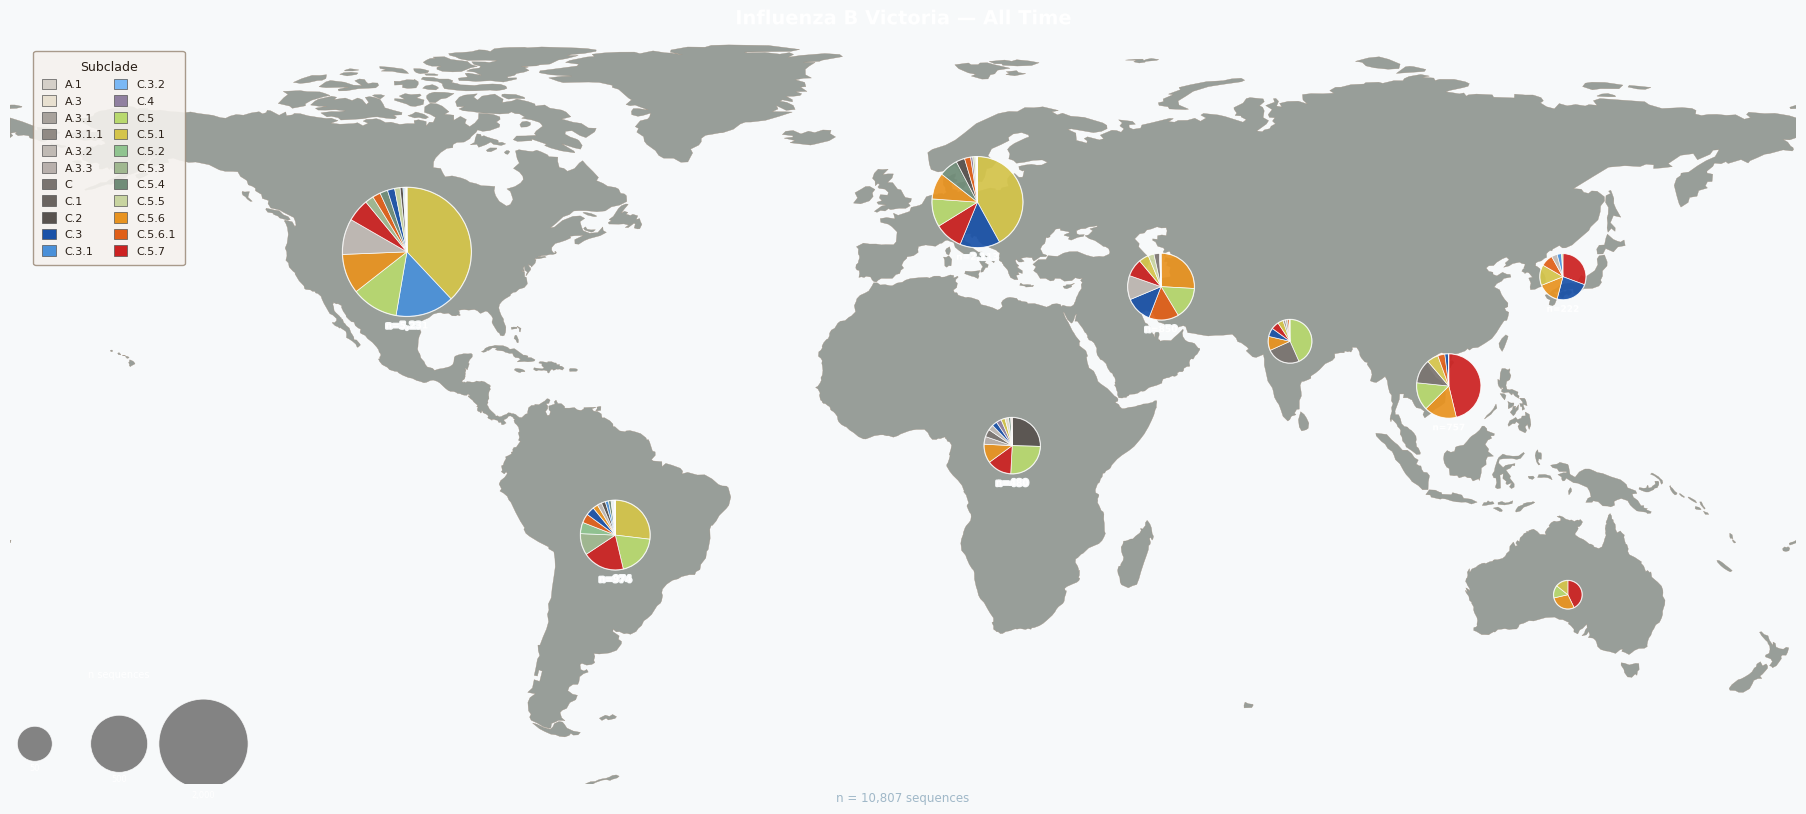

In [21]:
# --- All time (default settings) ---
fig, ax = plot_subclade_map(df, title="Influenza B Victoria — All Time")
plt.show()



Saved → ../figures/map_2024_25.png


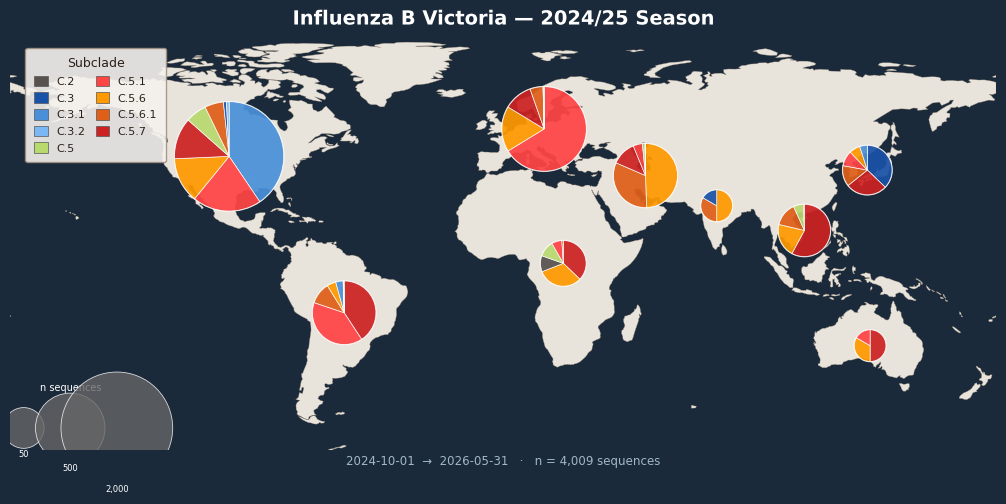

In [17]:
# --- Single season, custom colors, no n labels ---
fig, ax = plot_subclade_map(
    df,
    title        = "Influenza B Victoria — 2024/25 Season",
    date_start   = "2024-10-01",
    date_end     = "2026-05-31",
    color_dict   = {"C.5.1": "#ff4444", "C.5.6": "#ff9900"},  # override specific subclades
    figsize      = (10, 10),
    min_r        = 5.0,
    max_r        = 20.0,
    show_n_label = False,
    save_path    = "../figures/map_2024_25.png",
)
plt.show()

In [ ]:
# Refactored in Cartopy

In [ ]:
def plot_subclade_map(
    df,
    title           = "Influenza B Victoria — Subclade Frequency by Region",
    date_start      = None,
    date_end        = None,
    color_dict      = None,
    projection      = MAP_PROJECTION,
    figsize         = (18, 10),
    min_r           = DEFAULT_MIN_R,
    max_r           = DEFAULT_MAX_R,
    scale_to_self   = True,
    external_max_n  = None,
    show_n_label    = True,
    n_label_min_r   = 4.5,
    save_path       = None,
    dpi             = 180,
):
    """
    Plot a single subclade frequency map with pie charts per global region
    using Cartopy for projection support.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe with columns: country, subclade, date, custom_region.
    title : str
        Figure title.
    date_start : str or None
        ISO date "YYYY-MM-DD". Rows before this are excluded. None = no filter.
    date_end : str or None
        ISO date "YYYY-MM-DD". Rows after this are excluded. None = no filter.
    color_dict : dict or None
        Subclade → hex overrides merged on top of SUBCLADE_COLORS.
        Only supply keys you want to change.
    projection : cartopy CRS
        Map projection. Defaults to the global MAP_PROJECTION.
        Examples: ccrs.Robinson(), ccrs.Mollweide(), ccrs.EqualEarth(),
                  ccrs.NaturalEarth(), ccrs.Winkel3(), ccrs.PlateCarree()
    figsize : tuple
        Figure (width, height) in inches.
    min_r : float
        Minimum pie radius in degrees (converted to map units internally).
    max_r : float
        Maximum pie radius in degrees (for the largest region).
    scale_to_self : bool
        True  → sizes scaled to the largest region in THIS filtered window.
        False → use external_max_n for cross-panel consistent sizing.
    external_max_n : int or None
        Override max_n used for scaling. Only used when scale_to_self=False.
        Compute once as: df.groupby("custom_region").size().max()
    show_n_label : bool
        Print "n=X,XXX" beneath each pie.
    n_label_min_r : float
        Suppress n label for pies with degree-radius below this threshold.
    save_path : str or None
        File path to save figure. None = display inline only.
    dpi : int
        Resolution for saved figure.

    Returns
    -------
    fig, ax
    """

    # ── Filter by date FIRST ──────────────────────────────────────────────────
    fdf = df.copy()
    if date_start:
        fdf = fdf[fdf["date"] >= date_start]
    if date_end:
        fdf = fdf[fdf["date"] <= date_end]

    if fdf.empty:
        print("⚠️  No data in the specified date range.")
        return None, None

    # ── Build color scheme: grey defaults + selective highlights ──────────────
    # Get all unique subclades in filtered data
    all_subclades = sorted(fdf["subclade"].unique())
    
    # Start with grey palette for all subclades
    colors = _generate_grey_palette(all_subclades, start_grey=0.35, end_grey=0.75)
    
    # Override with global SUBCLADE_COLORS if any
    if SUBCLADE_COLORS:
        colors.update(SUBCLADE_COLORS)
    
    # Override with function argument color_dict (highest priority)
    if color_dict:
        colors.update(color_dict)

    # ── Aggregate ─────────────────────────────────────────────────────────────
    counts = (
        fdf.groupby(["custom_region", "subclade"])
        .size()
        .reset_index(name="n")
    )
    region_totals = counts.groupby("custom_region")["n"].sum()

    if scale_to_self or external_max_n is None:
        max_n = region_totals.max()
    else:
        max_n = external_max_n

    # ── Figure & Cartopy axes ─────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize, facecolor=MAP_FIG_BG_COLOR)
    ax  = fig.add_subplot(1, 1, 1, projection=projection)
    ax.set_global()
    ax.set_facecolor(MAP_OCEAN_COLOR)

    ax.add_feature(cfeature.LAND,      facecolor=MAP_LAND_COLOR,   zorder=1)
    ax.add_feature(cfeature.OCEAN,     facecolor=MAP_OCEAN_COLOR,  zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor=MAP_BORDER_COLOR,
                   linewidth=MAP_BORDER_LW + 0.1, zorder=2)
    ax.add_feature(cfeature.BORDERS,   edgecolor=MAP_BORDER_COLOR,
                   linewidth=MAP_BORDER_LW, zorder=2)

    # ── Add gridlines (lat/lon) ───────────────────────────────────────────────
    gl = ax.gridlines(
        crs=DATA_CRS,
        draw_labels=False,           # True adds degree labels (may not work with all projections)
        linewidth=0.5,
        color='#c0c0c0',             # light grey
        alpha=0.6,
        linestyle='--',              # dashed lines
        zorder=3                     # above land/ocean, below pies
    )
    gl.xlocator = plt.matplotlib.ticker.MultipleLocator(30)  # longitude every 30°
    gl.ylocator = plt.matplotlib.ticker.MultipleLocator(30)  # latitude every 30°

    # ── Draw pies ─────────────────────────────────────────────────────────────
    for region, grp in counts.groupby("custom_region"):
        lat, lon  = REGION_COORDS[region]
        total     = region_totals[region]

        # Degree radius → map units (metres for most projections)
        radius_deg = min_r + (max_r - min_r) * np.sqrt(total / max_n)
        radius     = _deg_to_map_units(lon, lat, radius_deg, projection)

        # Centre in projected coordinates
        cx, cy = projection.transform_point(lon, lat, DATA_CRS)

        slices    = grp.sort_values("n", ascending=False)
        angles    = (slices["n"] / total * 360).values
        subclades = slices["subclade"].values

        start = 90.0
        for angle, sc in zip(angles, subclades):
            wedge = Wedge(
                (cx, cy), radius,
                start - angle, start,
                facecolor=colors.get(sc, DEFAULT_COLOR),
                edgecolor=PIE_EDGE_COLOR,
                linewidth=PIE_EDGE_LW,
                alpha=PIE_ALPHA,
                transform=ax.transData,   # already in projected units
                zorder=5,
            )
            ax.add_patch(wedge)
            start -= angle

        ring = plt.Circle(
            (cx, cy), radius,
            fill=False, edgecolor=PIE_EDGE_COLOR,
            linewidth=PIE_RING_LW, alpha=PIE_RING_ALPHA,
            transform=ax.transData, zorder=6,
        )
        ax.add_patch(ring)

        # Optional n label — transform a point slightly below the pie back to
        # projected coords for text placement
        if show_n_label and radius_deg >= n_label_min_r:
            lx, ly = projection.transform_point(lon, lat - radius_deg - 1.2, DATA_CRS)
            ax.text(
                lx, ly,
                f"n={total:,}",
                ha="center", va="top",
                fontsize=6.5, color="black", fontweight="bold",
                transform=ax.transData, zorder=7,
                path_effects=[pe.withStroke(linewidth=2, foreground="white")],
            )

    # ── Legend ────────────────────────────────────────────────────────────────
    present = sorted(fdf["subclade"].unique())
    handles = [
        mpatches.Patch(
            facecolor=colors.get(sc, DEFAULT_COLOR),
            edgecolor="#555", linewidth=0.5, label=sc,
        )
        for sc in present
    ]
    legend = ax.legend(
        handles=handles,
        title="Subclade", title_fontsize=9,
        fontsize=8,
        loc="upper left", bbox_to_anchor=(0.01, 0.99),
        ncol=2,
        framealpha=0.90, facecolor="#f5f2ee",
        edgecolor="#a09080", labelcolor="#2a2018",
        handlelength=1.2, handleheight=1.1,
        columnspacing=0.9, borderpad=0.8,
    )
    legend.get_title().set_color("#2a2018")

    # ── Size reference bubbles (bottom-left, in projected coords) ─────────────
    # Anchor at a fixed lon/lat and convert to projected units
    ref_lon, ref_lat = -160.0, -52.0
    ref_sizes  = [50, 500, 1000, 2000]
    ref_labels = ["50", "500", "1,000", "2,000"]
    spacing_deg = 20.0

    ref_cx, ref_cy = projection.transform_point(ref_lon, ref_lat, DATA_CRS)
    _, label_top_y  = projection.transform_point(ref_lon, ref_lat + 14, DATA_CRS)

    ax.text(
        ref_cx + _deg_to_map_units(ref_lon, ref_lat, spacing_deg, projection),
        label_top_y,
        "n sequences",
        ha="center", va="bottom", fontsize=7, color="black",
        transform=ax.transData, zorder=10,
    )

    for i, (s, lbl) in enumerate(zip(ref_sizes, ref_labels)):
        r_deg = min_r + (max_r - min_r) * np.sqrt(s / max_n)
        r     = _deg_to_map_units(ref_lon, ref_lat, r_deg, projection)
        step  = _deg_to_map_units(ref_lon, ref_lat, spacing_deg, projection)
        bx    = ref_cx + i * step

        c = plt.Circle(
            (bx, ref_cy), r,
            facecolor="#666", edgecolor="black",
            linewidth=0.6, alpha=0.8,
            transform=ax.transData, zorder=10,
        )
        ax.add_patch(c)
        ax.text(
            bx, ref_cy - r,
            lbl, ha="center", va="top",
            fontsize=6, color="white",
            transform=ax.transData, zorder=10,
        )

    # ── Title & subtitle ──────────────────────────────────────────────────────
    subtitle_parts = []
    if date_start or date_end:
        s = date_start or "start"
        e = date_end   or "present"
        subtitle_parts.append(f"{s}  →  {e}")
    subtitle_parts.append(f"n = {len(fdf):,} sequences")
    subtitle = "   ·   ".join(subtitle_parts)

    ax.set_title(
        title,
        fontsize=14, fontweight="bold", color="black", pad=10,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )
    fig.text(
        0.5, 0.02, subtitle,
        ha="center", va="bottom",
        fontsize=8.5, color="black",
    )

    fig.patch.set_facecolor(MAP_FIG_BG_COLOR)
    plt.tight_layout(pad=0.3)

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")

    return fig, ax

# plot

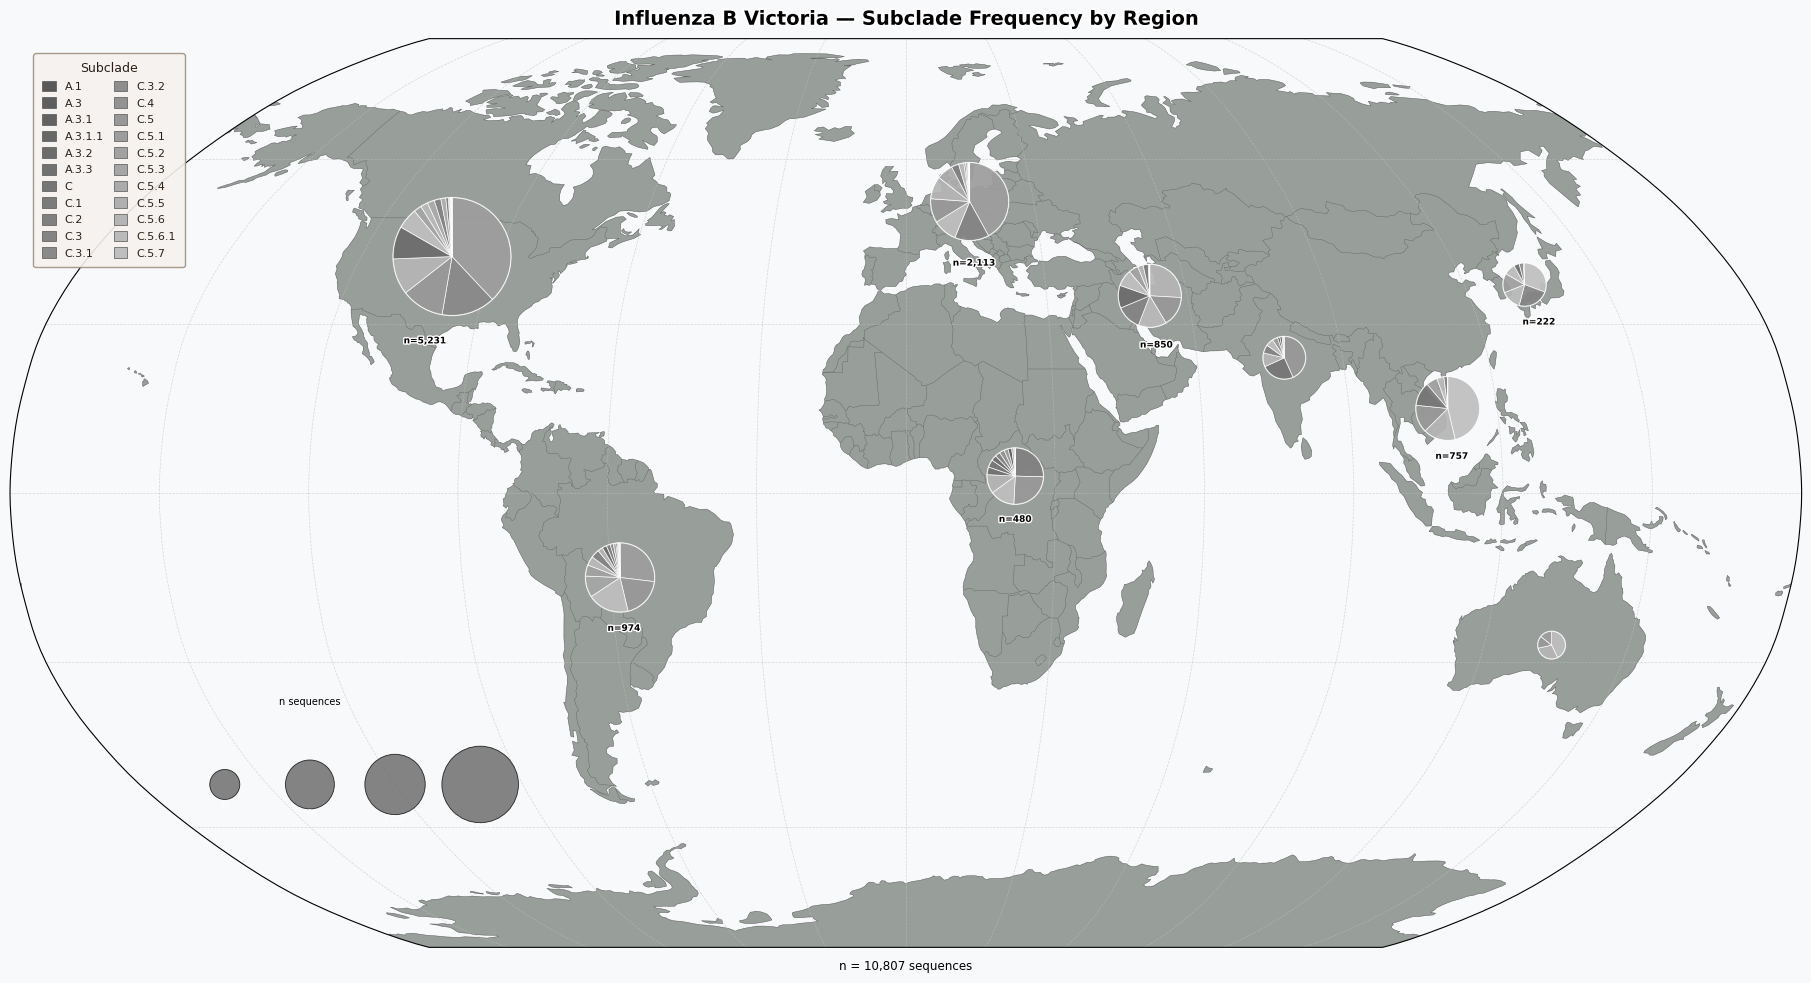

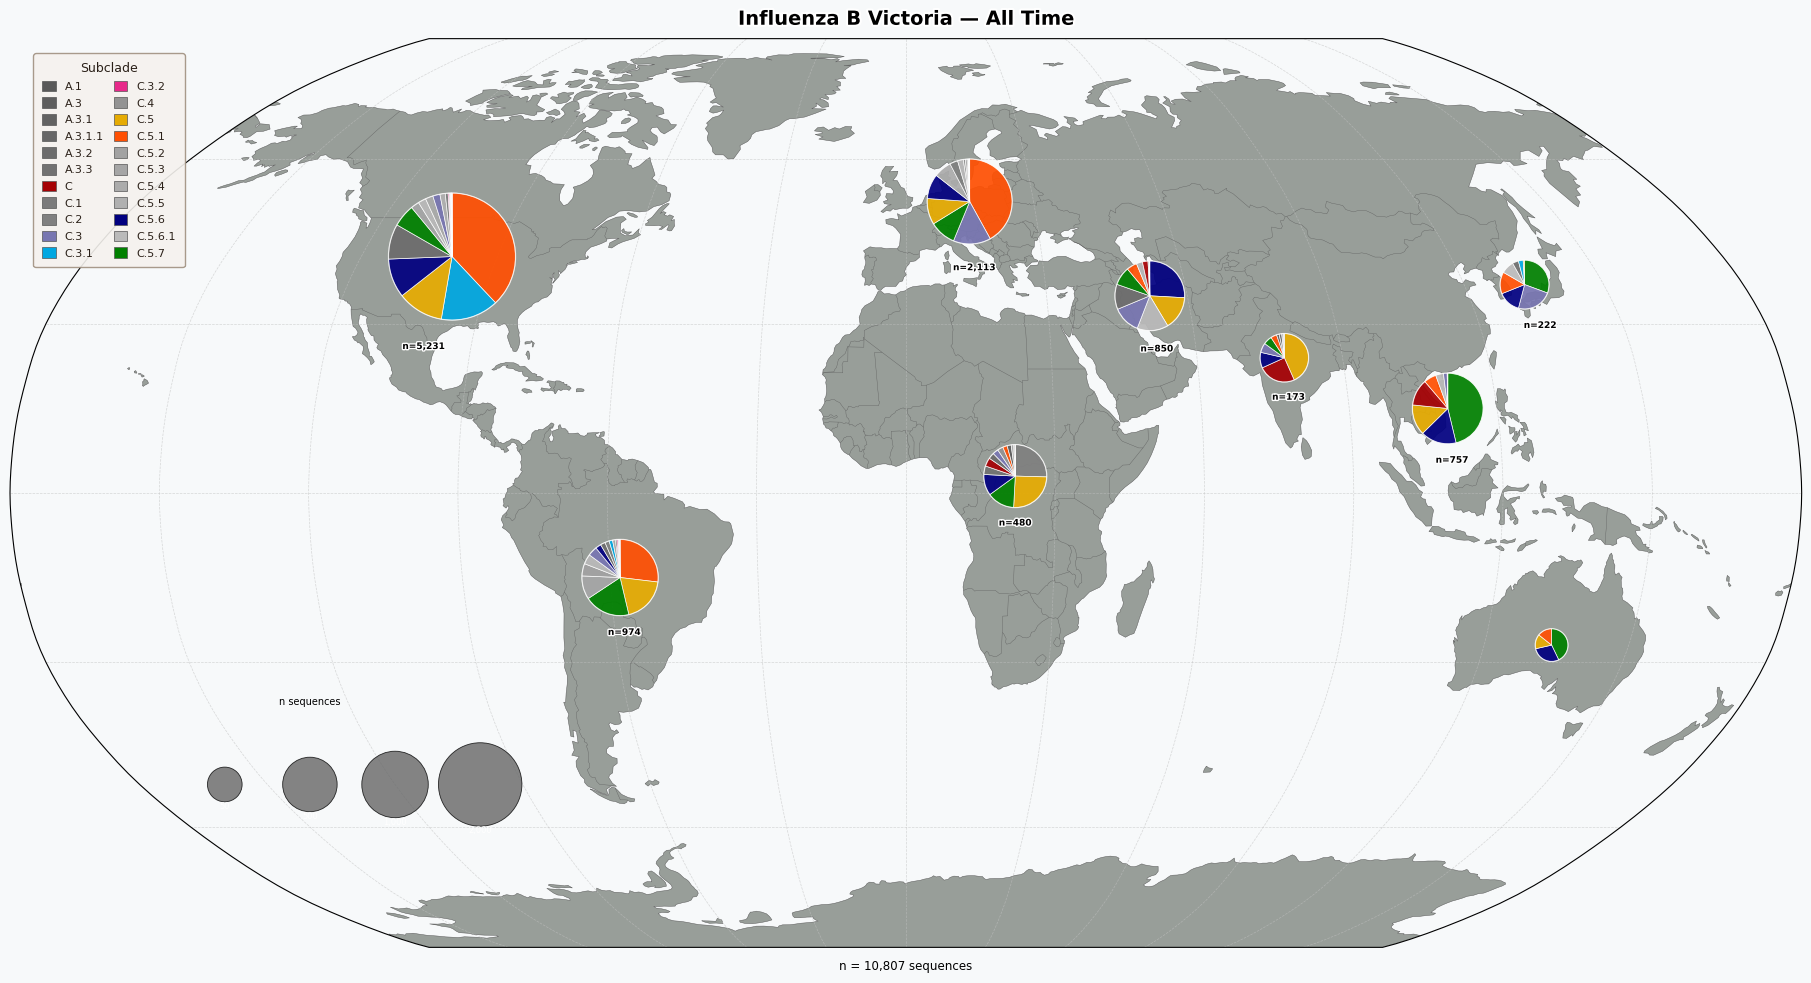

Saved → ../figures/map_2024_25.png


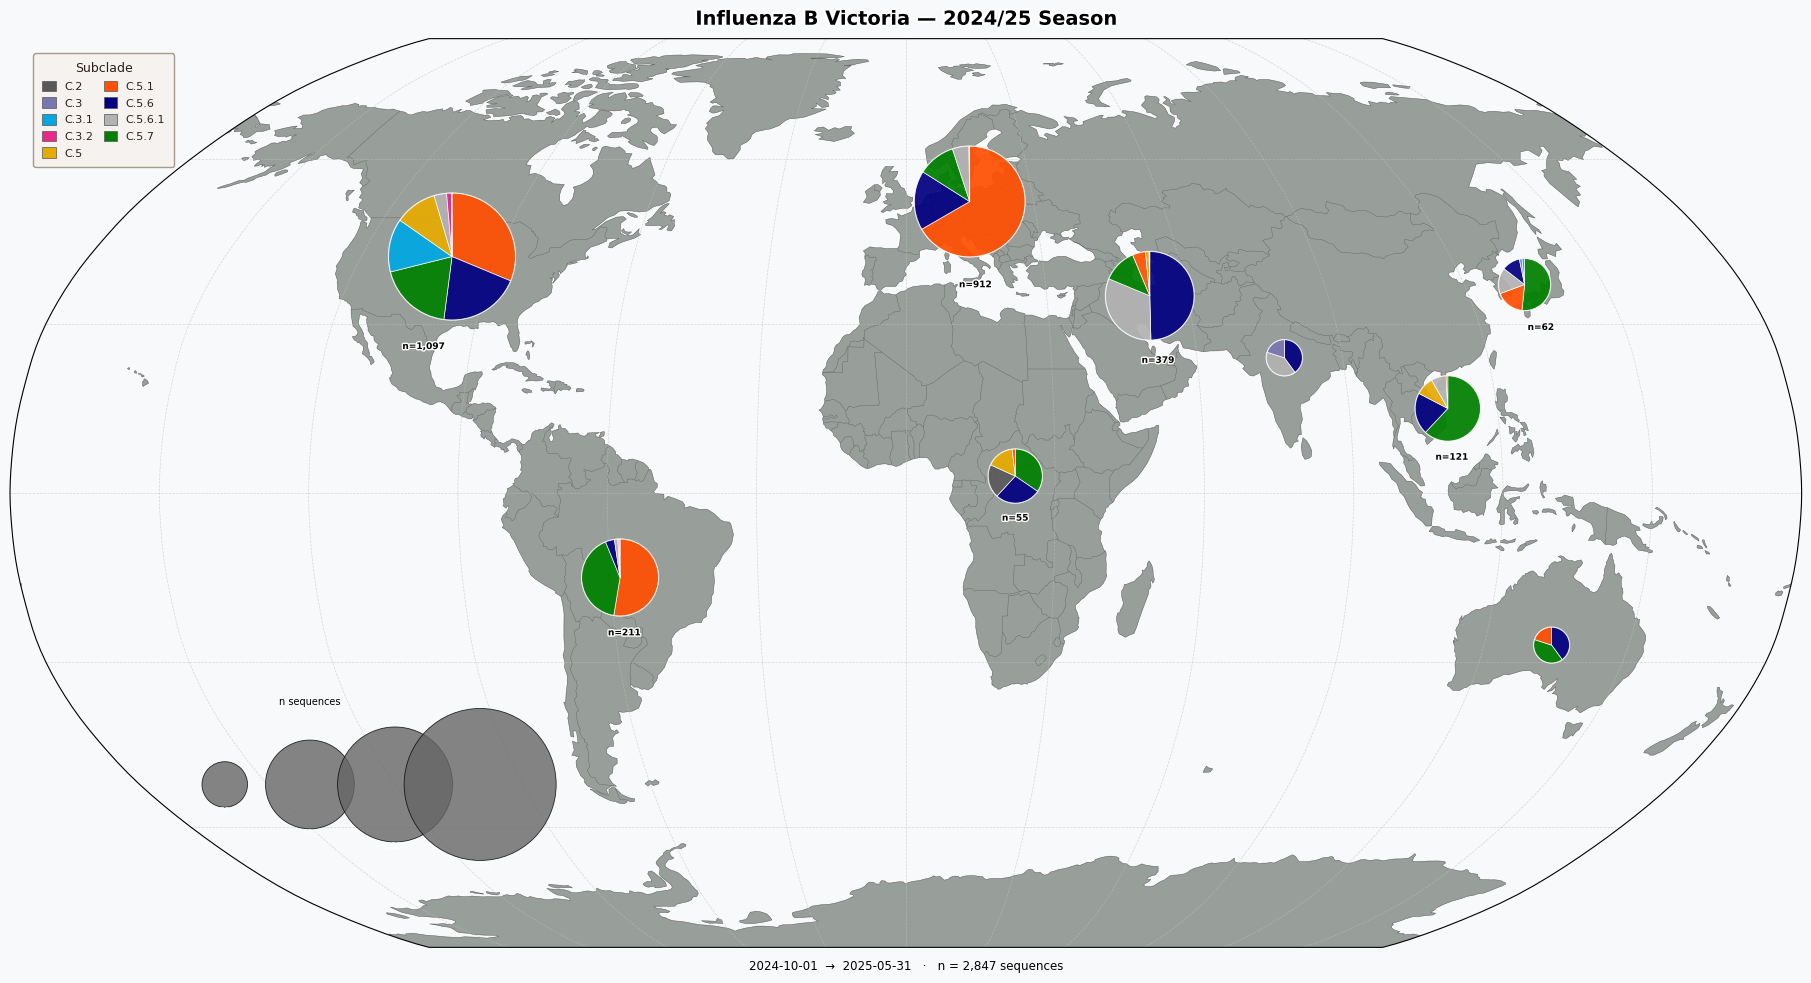

Saved → ../figures/map_2025_26.png


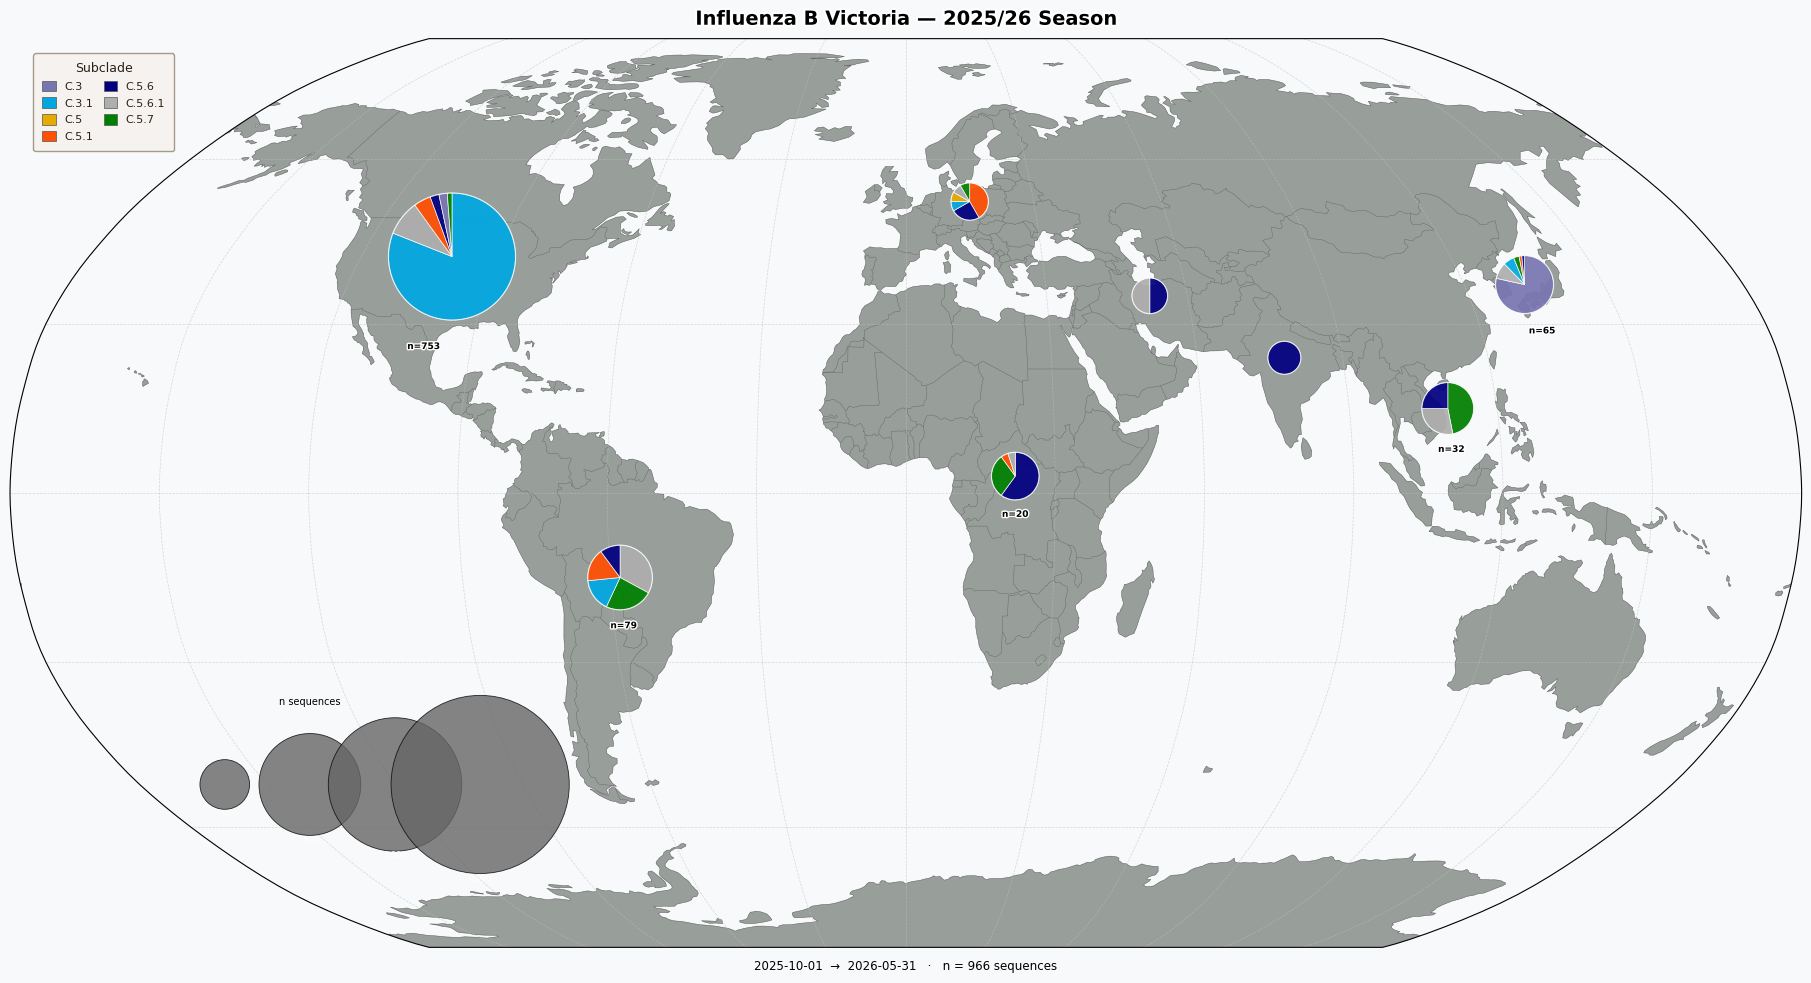

In [58]:
# define subclade color dictionary
highlight_colors = {
            "C.5.1": "#FF5003",
            "C.5.6": "#010080",
            "C.5.7": "green",
            "C.5": "#e6ab02",
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            "C.3.2": "#e7298a",
            "C": "#A50104" # vaccine
        }


# --- 2024-2025 Season ---
fig, ax = plot_subclade_map(df)
plt.show()

# --- 2024-2025 Season ---
fig, ax = plot_subclade_map(
    df,
    title        = "Influenza B Victoria — All Time",
    color_dict   = highlight_colors,
    figsize      = (18, 10),
    min_r        = 3.0,
    max_r        = 14.0,
    show_n_label = True
    )
plt.show()

# --- 2024-2025 Season ---
fig, ax = plot_subclade_map(
    df,
    title        = "Influenza B Victoria — 2024/25 Season",
    date_start   = "2024-10-01",
    date_end     = "2025-05-31",
    color_dict   = highlight_colors,
    figsize      = (18, 10),
    min_r        = 3.0,
    max_r        = 14.0,
    show_n_label = True,
    save_path    = "../figures/map_2024_25.png",
)
plt.show()

# --- 2025-2026 Season ---
fig, ax = plot_subclade_map(
    df,
    title        = "Influenza B Victoria — 2025/26 Season",
    date_start   = "2025-10-01",
    date_end     = "2026-05-31",
    color_dict   = highlight_colors,
    figsize      = (18, 10),
    min_r        = 3.0,
    max_r        = 14.0,
    show_n_label = True,
    save_path    = "../figures/map_2025_26.png",
)
plt.show()

✓ Saved 4-panel figure → ../figures/vic_4panel_highlighted.png


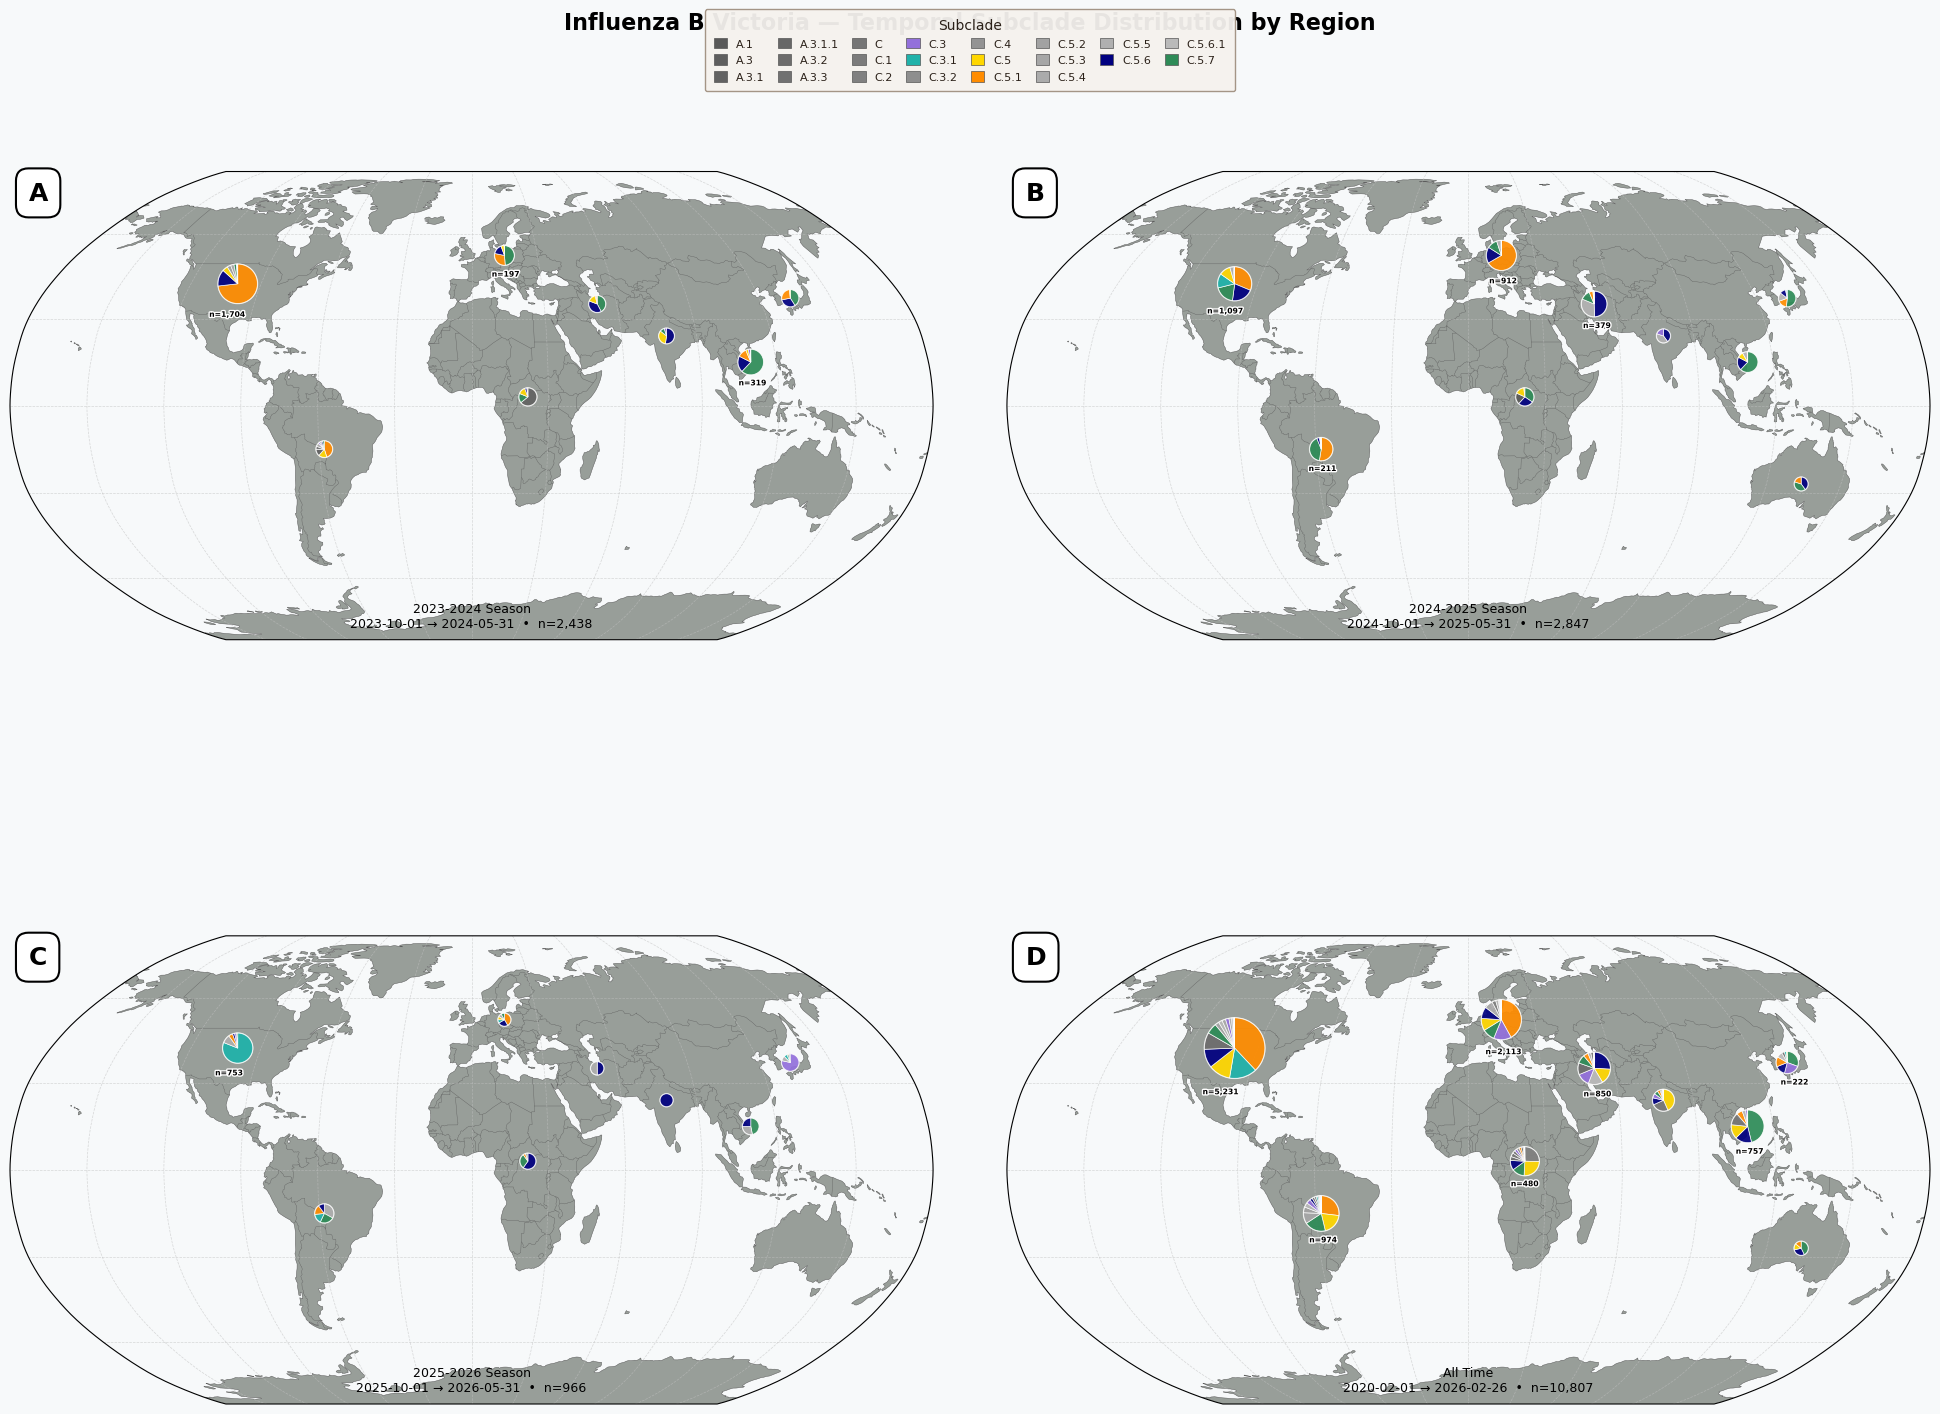

In [61]:
# 4 Panel Figure Function

# ══════════════════════════════════════════════════════════════════════════════
#  4-PANEL FIGURE FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def plot_4panel_temporal(
    df,
    color_dict=None,
    figsize=(20, 16),
    save_path=None,
    dpi=180,
):
    """
    Create a 4-panel figure showing subclade distribution across time periods.
    
    Panel A: Oct 2023 - May 2024
    Panel B: Oct 2024 - May 2025
    Panel C: Oct 2025 - May 2026
    Panel D: All time (earliest to latest sequence)
    
    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe with columns: country, subclade, date, custom_region.
    color_dict : dict or None
        Subclade → hex color overrides for highlighting specific subclades.
    figsize : tuple
        Figure (width, height) in inches.
    save_path : str or None
        File path to save figure. None = display inline only.
    dpi : int
        Resolution for saved figure.
    
    Returns
    -------
    fig, axes
    """
    
    # Define time periods
    periods = [
        {
            "label": "A",
            "title": "2023-2024 Season",
            "start": "2023-10-01",
            "end": "2024-05-31",
        },
        {
            "label": "B",
            "title": "2024-2025 Season",
            "start": "2024-10-01",
            "end": "2025-05-31",
        },
        {
            "label": "C",
            "title": "2025-2026 Season",
            "start": "2025-10-01",
            "end": "2026-05-31",
        },
        {
            "label": "D",
            "title": "All Time",
            "start": None,
            "end": None,
        },
    ]
    
    # For Panel D, get actual date range
    earliest = df["date"].min().strftime("%Y-%m-%d")
    latest = df["date"].max().strftime("%Y-%m-%d")
    
    # Calculate global max_n for consistent pie sizing across all panels
    external_max_n = df.groupby("custom_region").size().max()
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=figsize, facecolor=MAP_FIG_BG_COLOR)
    
    # Create GridSpec for custom spacing
    from matplotlib.gridspec import GridSpec
    gs = GridSpec(2, 2, figure=fig, hspace=0.08, wspace=0.08,
                  left=0.02, right=0.98, top=0.96, bottom=0.04)
    
    axes = []
    
    for idx, period in enumerate(periods):
        row = idx // 2
        col = idx % 2
        
        # Create subplot with projection
        ax = fig.add_subplot(gs[row, col], projection=MAP_PROJECTION)
        axes.append(ax)
        
        # Set date range (use actual dates for Panel D)
        if period["label"] == "D":
            date_start = earliest
            date_end = latest
        else:
            date_start = period["start"]
            date_end = period["end"]
        
        # Filter data
        fdf = df.copy()
        if date_start:
            fdf = fdf[fdf["date"] >= date_start]
        if date_end:
            fdf = fdf[fdf["date"] <= date_end]
        
        if fdf.empty:
            print(f"⚠️  No data for Panel {period['label']}")
            continue
        
        # Build color scheme
        all_subclades = sorted(fdf["subclade"].unique())
        colors = _generate_grey_palette(all_subclades, start_grey=0.35, end_grey=0.75)
        if SUBCLADE_COLORS:
            colors.update(SUBCLADE_COLORS)
        if color_dict:
            colors.update(color_dict)
        
        # Aggregate
        counts = (
            fdf.groupby(["custom_region", "subclade"])
            .size()
            .reset_index(name="n")
        )
        region_totals = counts.groupby("custom_region")["n"].sum()
        
        # Setup map
        ax.set_global()
        ax.set_facecolor(MAP_OCEAN_COLOR)
        
        ax.add_feature(cfeature.LAND, facecolor=MAP_LAND_COLOR, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor=MAP_OCEAN_COLOR, zorder=0)
        ax.add_feature(cfeature.COASTLINE, edgecolor=MAP_BORDER_COLOR,
                       linewidth=MAP_BORDER_LW + 0.1, zorder=2)
        ax.add_feature(cfeature.BORDERS, edgecolor=MAP_BORDER_COLOR,
                       linewidth=MAP_BORDER_LW, zorder=2)
        
        # Add gridlines
        gl = ax.gridlines(
            crs=DATA_CRS,
            draw_labels=False,
            linewidth=0.5,
            color='#c0c0c0',
            alpha=0.6,
            linestyle='--',
            zorder=3
        )
        gl.xlocator = plt.matplotlib.ticker.MultipleLocator(30)
        gl.ylocator = plt.matplotlib.ticker.MultipleLocator(30)
        
        # Draw pies
        for region, grp in counts.groupby("custom_region"):
            lat, lon = REGION_COORDS[region]
            total = region_totals[region]
            
            radius_deg = DEFAULT_MIN_R + (DEFAULT_MAX_R - DEFAULT_MIN_R) * np.sqrt(total / external_max_n)
            radius = _deg_to_map_units(lon, lat, radius_deg, MAP_PROJECTION)
            
            cx, cy = MAP_PROJECTION.transform_point(lon, lat, DATA_CRS)
            
            slices = grp.sort_values("n", ascending=False)
            angles = (slices["n"] / total * 360).values
            subclades = slices["subclade"].values
            
            start = 90.0
            for angle, sc in zip(angles, subclades):
                wedge = Wedge(
                    (cx, cy), radius,
                    start - angle, start,
                    facecolor=colors.get(sc, DEFAULT_COLOR),
                    edgecolor=PIE_EDGE_COLOR,
                    linewidth=PIE_EDGE_LW,
                    alpha=PIE_ALPHA,
                    transform=ax.transData,
                    zorder=5,
                )
                ax.add_patch(wedge)
                start -= angle
            
            ring = plt.Circle(
                (cx, cy), radius,
                fill=False, edgecolor=PIE_EDGE_COLOR,
                linewidth=PIE_RING_LW, alpha=PIE_RING_ALPHA,
                transform=ax.transData, zorder=6,
            )
            ax.add_patch(ring)
            
            # n labels (smaller for multi-panel)
            if radius_deg >= 4.5:
                lx, ly = MAP_PROJECTION.transform_point(lon, lat - radius_deg - 1.2, DATA_CRS)
                ax.text(
                    lx, ly,
                    f"n={total:,}",
                    ha="center", va="top",
                    fontsize=5.5, color="black", fontweight="bold",
                    transform=ax.transData, zorder=7,
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")],
                )
        
        # Panel label and title
        ax.text(
            0.02, 0.98,
            f"{period['label']}",
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            ha="left", va="top",
            color="black",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", linewidth=1.5),
            zorder=20,
        )
        
        # Subtitle with date range and n
        if period["label"] == "D":
            subtitle = f"{earliest} → {latest}  •  n={len(fdf):,}"
        else:
            subtitle = f"{date_start} → {date_end}  •  n={len(fdf):,}"
        
        ax.text(
            0.5, 0.02,
            f"{period['title']}\n{subtitle}",
            transform=ax.transAxes,
            fontsize=9, ha="center", va="bottom",
            color="black",
            zorder=20,
        )
    
    # Add shared legend (top center, outside plots)
    all_subclades_global = sorted(df["subclade"].unique())
    colors_global = _generate_grey_palette(all_subclades_global, start_grey=0.35, end_grey=0.75)
    if SUBCLADE_COLORS:
        colors_global.update(SUBCLADE_COLORS)
    if color_dict:
        colors_global.update(color_dict)
    
    handles = [
        mpatches.Patch(
            facecolor=colors_global.get(sc, DEFAULT_COLOR),
            edgecolor="#555", linewidth=0.5, label=sc,
        )
        for sc in all_subclades_global
    ]
    
    legend = fig.legend(
        handles=handles,
        title="Subclade",
        title_fontsize=10,
        fontsize=8,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=min(len(all_subclades_global), 8),
        framealpha=0.95,
        facecolor="#f5f2ee",
        edgecolor="#a09080",
        labelcolor="#2a2018",
        handlelength=1.2,
        handleheight=1.1,
        columnspacing=1.2,
        borderpad=0.8,
    )
    legend.get_title().set_color("#2a2018")
    
    # Overall title
    fig.suptitle(
        "Influenza B Victoria — Temporal Subclade Distribution by Region",
        fontsize=16, fontweight="bold", color="black", y=0.985,
    )
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"✓ Saved 4-panel figure → {save_path}")
    
    return fig, axes


# ══════════════════════════════════════════════════════════════════════════════
#  USAGE EXAMPLE
# ══════════════════════════════════════════════════════════════════════════════


# Example 2: Highlight specific subclades
fig, axes = plot_4panel_temporal(
    df,
    color_dict={
        "C.3": "#9370DB",      # purple
        "C.3.1": "#20B2AA",    # teal
        "C.5": "#FFD700",      # yellow
        "C.5.1": "#FF8C00",    # orange
        "C.5.6": "#000080",    # navy
        "C.5.7": "#2E8B57",    # green
    },
    save_path="../figures/vic_4panel_highlighted.png"
)
plt.show()

In [63]:
# ══════════════════════════════════════════════════════════════════════════════
#  DIAGNOSTIC SCRIPT - DATA FILTERING ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def diagnose_data_filtering(df, verbose=True):
    """
    Analyze how many rows are being filtered at each step of the pipeline.
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw dataframe loaded from TSV
    verbose : bool
        Print detailed breakdown by country/region
    
    Returns
    -------
    dict with filtering statistics
    """
    
    print("=" * 80)
    print("DATA FILTERING DIAGNOSTIC REPORT")
    print("=" * 80)
    
    stats = {}
    
    # ── Step 0: Original data ─────────────────────────────────────────────────
    total_original = len(df)
    stats['original'] = total_original
    print(f"\n📊 STEP 0: Original data")
    print(f"   Total rows: {total_original:,}")
    
    # ── Step 1: Missing country ───────────────────────────────────────────────
    missing_country = df["country"].isna().sum()
    has_country = df["country"].notna()
    stats['missing_country'] = missing_country
    stats['has_country'] = has_country.sum()
    
    print(f"\n📊 STEP 1: Filter by country presence")
    print(f"   ✓ Has country: {has_country.sum():,}")
    print(f"   ✗ Missing country: {missing_country:,} ({missing_country/total_original*100:.2f}%)")
    
    # ── Step 2: Missing subclade ──────────────────────────────────────────────
    df_temp = df[has_country].copy()
    missing_subclade = df_temp["subclade"].isna().sum()
    has_subclade = df_temp["subclade"].notna()
    stats['missing_subclade'] = missing_subclade
    stats['has_both_country_subclade'] = has_subclade.sum()
    
    print(f"\n📊 STEP 2: Filter by subclade presence (among rows with country)")
    print(f"   ✓ Has subclade: {has_subclade.sum():,}")
    print(f"   ✗ Missing subclade: {missing_subclade:,} ({missing_subclade/len(df_temp)*100:.2f}%)")
    
    # ── Step 3: Custom region mapping ─────────────────────────────────────────
    df_temp = df_temp[has_subclade].copy()
    df_temp["country"] = df_temp["country"].str.strip()
    df_temp["custom_region"] = df_temp["country"].map(COUNTRY_TO_REGION)
    
    missing_region = df_temp["custom_region"].isna().sum()
    has_region = df_temp["custom_region"].notna()
    stats['missing_region_mapping'] = missing_region
    stats['has_region'] = has_region.sum()
    
    print(f"\n📊 STEP 3: Map country → custom region")
    print(f"   ✓ Mapped to region: {has_region.sum():,}")
    print(f"   ✗ No region mapping: {missing_region:,} ({missing_region/len(df_temp)*100:.2f}%)")
    
    if missing_region > 0 and verbose:
        unmapped_countries = df_temp[df_temp["custom_region"].isna()]["country"].value_counts()
        print(f"\n   ⚠️  Countries without region mapping:")
        for country, count in unmapped_countries.head(20).items():
            print(f"      • {country}: {count:,} sequences")
        if len(unmapped_countries) > 20:
            print(f"      ... and {len(unmapped_countries) - 20} more countries")
    
    # ── Step 4: Missing date ──────────────────────────────────────────────────
    df_temp = df_temp[has_region].copy()
    df_temp["date"] = pd.to_datetime(df_temp["date"], errors="coerce")
    missing_date = df_temp["date"].isna().sum()
    has_date = df_temp["date"].notna()
    stats['missing_date'] = missing_date
    stats['final_kept'] = has_date.sum()
    
    print(f"\n📊 STEP 4: Filter by date validity")
    print(f"   ✓ Valid date: {has_date.sum():,}")
    print(f"   ✗ Missing/invalid date: {missing_date:,} ({missing_date/len(df_temp)*100:.2f}%)")
    
    # ── Final summary ─────────────────────────────────────────────────────────
    final_df = df_temp[has_date].copy()
    total_dropped = total_original - len(final_df)
    
    print(f"\n" + "=" * 80)
    print(f"SUMMARY")
    print(f"=" * 80)
    print(f"Started with:        {total_original:,} sequences")
    print(f"Final dataset:       {len(final_df):,} sequences")
    print(f"Total dropped:       {total_dropped:,} sequences ({total_dropped/total_original*100:.2f}%)")
    print(f"\nRetention rate:      {len(final_df)/total_original*100:.2f}%")
    
    # ── Breakdown by filter reason ────────────────────────────────────────────
    print(f"\n📉 SEQUENCES DROPPED BY REASON:")
    print(f"   Missing country:           {missing_country:,}")
    print(f"   Missing subclade:          {missing_subclade:,}")
    print(f"   Country not in region map: {missing_region:,}")
    print(f"   Missing/invalid date:      {missing_date:,}")
    
    # ── Regional distribution ─────────────────────────────────────────────────
    print(f"\n" + "=" * 80)
    print(f"FINAL DATA DISTRIBUTION BY REGION")
    print(f"=" * 80)
    region_counts = final_df["custom_region"].value_counts()
    for region, count in region_counts.items():
        pct = count / len(final_df) * 100
        print(f"   {region:20s}: {count:6,} ({pct:5.2f}%)")
    
    # ── Countries in final dataset ────────────────────────────────────────────
    if verbose:
        print(f"\n" + "=" * 80)
        print(f"TOP 30 COUNTRIES IN FINAL DATASET")
        print(f"=" * 80)
        country_counts = final_df["country"].value_counts().head(30)
        for country, count in country_counts.items():
            region = COUNTRY_TO_REGION.get(country, "Unknown")
            pct = count / len(final_df) * 100
            print(f"   {country:35s} ({region:15s}): {count:6,} ({pct:5.2f}%)")
    
    # ── Date range ────────────────────────────────────────────────────────────
    print(f"\n" + "=" * 80)
    print(f"DATE RANGE")
    print(f"=" * 80)
    print(f"   Earliest: {final_df['date'].min().strftime('%Y-%m-%d')}")
    print(f"   Latest:   {final_df['date'].max().strftime('%Y-%m-%d')}")
    print(f"   Span:     {(final_df['date'].max() - final_df['date'].min()).days} days")
    
    # ── Subclade distribution ─────────────────────────────────────────────────
    print(f"\n" + "=" * 80)
    print(f"SUBCLADE DISTRIBUTION")
    print(f"=" * 80)
    subclade_counts = final_df["subclade"].value_counts()
    for sc, count in subclade_counts.items():
        pct = count / len(final_df) * 100
        print(f"   {sc:15s}: {count:6,} ({pct:5.2f}%)")
    
    print(f"\n" + "=" * 80)
    
    return stats, final_df


# ══════════════════════════════════════════════════════════════════════════════
#  CHECK FOR UNMAPPED COUNTRIES - DETAILED VERSION
# ══════════════════════════════════════════════════════════════════════════════

def find_unmapped_countries(df):
    """
    Find all countries that have data but aren't in COUNTRY_TO_REGION mapping.
    
    Returns a DataFrame with unmapped countries and their sequence counts.
    """
    
    print("=" * 80)
    print("UNMAPPED COUNTRIES ANALYSIS")
    print("=" * 80)
    
    # Get countries with valid data
    valid_df = df[df["country"].notna() & df["subclade"].notna()].copy()
    valid_df["country"] = valid_df["country"].str.strip()
    
    # Check which are unmapped
    valid_df["has_mapping"] = valid_df["country"].map(COUNTRY_TO_REGION).notna()
    
    unmapped = valid_df[~valid_df["has_mapping"]].copy()
    
    if len(unmapped) == 0:
        print("\n✓ All countries with data are mapped to regions!")
        return pd.DataFrame()
    
    # Count by country
    unmapped_summary = (
        unmapped.groupby("country")
        .agg({
            "subclade": "count",
            "date": lambda x: f"{x.min().strftime('%Y-%m-%d')} to {x.max().strftime('%Y-%m-%d')}"
        })
        .rename(columns={"subclade": "n_sequences", "date": "date_range"})
        .sort_values("n_sequences", ascending=False)
    )
    
    print(f"\n⚠️  Found {len(unmapped_summary)} unmapped countries with {len(unmapped):,} sequences\n")
    print(unmapped_summary.to_string())
    
    # Generate code to add to COUNTRY_TO_REGION
    print(f"\n" + "=" * 80)
    print("SUGGESTED ADDITIONS TO COUNTRY_TO_REGION:")
    print("=" * 80)
    print("\n# Add these lines to your COUNTRY_TO_REGION dictionary:\n")
    
    for country in unmapped_summary.index:
        # Try to suggest a region (you'll need to manually verify)
        print(f'    "{country}": "REGION_NAME",  # TODO: assign correct region')
    
    return unmapped_summary


# ══════════════════════════════════════════════════════════════════════════════
#  COMPARE BEFORE/AFTER FILTERING
# ══════════════════════════════════════════════════════════════════════════════

def compare_filtering_by_region(df):
    """
    Show how many sequences each region loses due to missing dates or other filters.
    """
    
    print("=" * 80)
    print("REGIONAL FILTERING IMPACT")
    print("=" * 80)
    
    # Apply country/subclade filters
    step1 = df[df["country"].notna() & df["subclade"].notna()].copy()
    step1["country"] = step1["country"].str.strip()
    step1["custom_region"] = step1["country"].map(COUNTRY_TO_REGION)
    
    # Before date filter
    before = step1[step1["custom_region"].notna()].copy()
    before_counts = before["custom_region"].value_counts()
    
    # After date filter
    before["date"] = pd.to_datetime(before["date"], errors="coerce")
    after = before[before["date"].notna()].copy()
    after_counts = after["custom_region"].value_counts()
    
    # Compare
    print(f"\n{'Region':<20s} {'Before Date Filter':>18s} {'After Date Filter':>18s} {'Lost':>10s} {'% Lost':>8s}")
    print("-" * 80)
    
    all_regions = sorted(set(before_counts.index) | set(after_counts.index))
    
    for region in all_regions:
        before_n = before_counts.get(region, 0)
        after_n = after_counts.get(region, 0)
        lost = before_n - after_n
        pct_lost = (lost / before_n * 100) if before_n > 0 else 0
        
        print(f"{region:<20s} {before_n:>18,} {after_n:>18,} {lost:>10,} {pct_lost:>7.2f}%")
    
    total_before = before_counts.sum()
    total_after = after_counts.sum()
    total_lost = total_before - total_after
    
    print("-" * 80)
    print(f"{'TOTAL':<20s} {total_before:>18,} {total_after:>18,} {total_lost:>10,} {total_lost/total_before*100:>7.2f}%")
    print()


# ══════════════════════════════════════════════════════════════════════════════
#  RUN ALL DIAGNOSTICS
# ══════════════════════════════════════════════════════════════════════════════

# Run full diagnostic
stats, final_df = diagnose_data_filtering(df, verbose=True)

print("\n\n")

# Find unmapped countries
unmapped = find_unmapped_countries(df)

print("\n\n")

# Regional filtering impact
compare_filtering_by_region(df)

# Save unmapped countries to file for reference
if len(unmapped) > 0:
    unmapped.to_csv("unmapped_countries.csv")
    print(f"\n💾 Saved unmapped countries to: unmapped_countries.csv")

DATA FILTERING DIAGNOSTIC REPORT

📊 STEP 0: Original data
   Total rows: 10,807

📊 STEP 1: Filter by country presence
   ✓ Has country: 10,807
   ✗ Missing country: 0 (0.00%)

📊 STEP 2: Filter by subclade presence (among rows with country)
   ✓ Has subclade: 10,807
   ✗ Missing subclade: 0 (0.00%)

📊 STEP 3: Map country → custom region
   ✓ Mapped to region: 10,807
   ✗ No region mapping: 0 (0.00%)

📊 STEP 4: Filter by date validity
   ✓ Valid date: 10,807
   ✗ Missing/invalid date: 0 (0.00%)

SUMMARY
Started with:        10,807 sequences
Final dataset:       10,807 sequences
Total dropped:       0 sequences (0.00%)

Retention rate:      100.00%

📉 SEQUENCES DROPPED BY REASON:
   Missing country:           0
   Missing subclade:          0
   Country not in region map: 0
   Missing/invalid date:      0

FINAL DATA DISTRIBUTION BY REGION
   North America       :  5,231 (48.40%)
   Europe              :  2,113 (19.55%)
   South America       :    974 ( 9.01%)
   West Asia           :    